# eCooking time-of-use tariffs in solar mini-grids — v4 (Phase 1)

**AEF Nairobi 2026 · Rwanda (Nkombo) and Kenya (Ringiti)**

## Phase 1 corrections applied in this version

1. **RAMP is now seeded.** `build_noncooking_load` accepted a `seed` and
   ignored it. RAMP 0.5.0 draws from the *stdlib* `random`, not `np.random`,
   so seeding numpy would not have fixed it. Eight calls at `seed=42`
   previously gave eight different profiles, with the aggregate peak ranging
   5.89–6.83 kW. Peak sets battery capacity, so this — not the discrete
   sizing grid — is what produced the ±20 kWh differences between matched
   flat and ToU arms.
2. **OPEX basis is explicit.** `per_customer_year` was defined in the config
   and read nowhere; `financials()` used 4% of CAPEX + staff. §3.7 describes
   the per-customer basis, which is now the default. Effect at full
   penetration: LCOE −15% (Rwanda), −14% (Kenya); cost-reflective multiple
   10.9× → 9.4× and 11.6× → 10.2×.
3. **A capital grant no longer cuts operating cost.** OPEX was a fraction of
   *post*-grant CAPEX, so a 95% grant cut O&M by 95%.
4. **Appliances derived from each country's own MTF — option (a), done.**
   Rwanda silently ran on the Kenyan appliance stock. Both sets now come from
   their own microdata by the same method, weighted, on the same denominator.
   Rwanda's real appliance demand is **2.9x Kenya's**, which reverses §3.2's
   premise and turns §5.1's failed prediction into a confirmed one: the
   headline LCOE reduction is **60% in Rwanda and 83% in Kenya** (published:
   58% and 60%).
5. **Diesel is declared.** Every published scenario ran `diesel_kw = 0`.
6. **Curtailment is reported.** It was computed hourly and discarded. It runs
   at 46–49% at full penetration.

**Still open (needs the microdata, which is not in this notebook's history):**
`src/extract_mtf.py` reads `SECTION_I.csv` for Rwandan "appliance ownership".
Per the published data dictionary, `SECTION_I` is the **fuel** section: `I02`
is *Fuel*, `I03` is *used fuel*. Rwandan appliances are in `SECTION_EF1`
(`E01A`–`E37B`), which the pipeline never opened. Run
`src/extract_mtf_rwanda.py` (§5b) before trusting any Rwandan appliance or
firewood figure.

Run cell 1, **restart the session**, then run everything below.

## 1 · Install — then Runtime → Restart session

In [1]:
!pip install -q "numpy<2" "pandas<2.2" rampdemand==0.5.0 numpy-financial pyyaml pytest 2>&1 | tail -2
print("\n" + "="*56 + "\nNOW: Runtime -> Restart session, then continue\n" + "="*56)


NOW: Runtime -> Restart session, then continue


## 2 · Setup

In [2]:
import numpy, pandas, sys
assert numpy.__version__.startswith("1."), "restart the session first"
print("numpy", numpy.__version__, "| pandas", pandas.__version__)

import os
from pathlib import Path
USE_DRIVE = False          # True keeps results across disconnects
if USE_DRIVE:
    from google.colab import drive; drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/ecooking_aef")
else:
    ROOT = Path("/content/ecooking_aef")
for d in ["src","tests","data/raw","data/processed","results","figs"]:
    (ROOT/d).mkdir(parents=True, exist_ok=True)
os.chdir(ROOT); sys.path.insert(0, str(ROOT/"src"))
print("ROOT =", ROOT)

numpy 1.26.4 | pandas 2.1.4
ROOT = /content/ecooking_aef


## 3 · Source modules

In [ ]:
%%writefile src/model.py
"""Microgrid technical + financial model, refactored for scenario sweeps.

Derived from achilala_ESM_Assignment9. Structural changes:
  * No global state. Everything takes a cfg dict -> scenarios can be swept.
  * Battery: round-trip efficiency, depth-of-discharge floor, applied fade.
  * Wind removed (the original returned rated power regardless of wind speed).
  * Resource data comes from NASA POWER hourly, not daily interpolation.
  * LCOE added.
  * Time-of-use tariffs added.
  * Seeded RNG -> reproducible.
"""
from dataclasses import dataclass, field

import numpy as np
import numpy_financial as npf
import pandas as pd

HOURS = 8760


# ----------------------------------------------------------------- components
class PVGenerator:
    def __init__(self, capacity_kw, temp_coeff=-0.004, noct=45.0, degradation=0.008):
        self.capacity_kw = capacity_kw
        self.temp_coeff = temp_coeff
        self.noct = noct
        self.degradation = degradation

    def output(self, ghi, tair, year_index):
        """Vectorised DC output (kW) for an array of hours."""
        tcell = tair + (ghi / 800.0) * (self.noct - 20.0)
        p = self.capacity_kw * (ghi / 1000.0) * (1 + self.temp_coeff * (tcell - 25.0))
        p = np.maximum(p, 0.0)
        return p * (1 - self.degradation) ** (year_index - 1)


class Battery:
    """Bucket model with round-trip efficiency, DoD floor and applied fade.

    Renamed from KiBaM: this is not a kinetic two-tank model and should not
    claim to be one.
    """

    def __init__(self, capacity_kwh, rte=0.90, dod=0.80, cycle_life=3000,
                 start_soc_fraction=0.5, max_c_rate=0.5, eol_capacity_loss=0.2):
        self.nominal = capacity_kwh
        self.usable = capacity_kwh * dod
        self.eta_1way = np.sqrt(rte)          # split RTE across charge+discharge
        self.dod = dod
        self.throughput_limit = capacity_kwh * dod * cycle_life
        self.max_power_kw = capacity_kwh * max_c_rate
        self.eol_capacity_loss = eol_capacity_loss
        self.soc = self.usable * start_soc_fraction
        self.cumulative_discharge = 0.0
        self.energy_in = 0.0                  # DC into the cell, for audit
        self.energy_out = 0.0                 # DC out of the cell, for audit

    @property
    def fade(self):
        if self.throughput_limit <= 0:
            return 0.0
        return min(self.cumulative_discharge / self.throughput_limit, 1.0)

    def effective_capacity(self):
        return self.usable * (1 - self.eol_capacity_loss * self.fade)

    def _clamp(self):
        """Fade shrinks capacity; stored energy above the new ceiling is lost."""
        cap = self.effective_capacity()
        if self.soc > cap:
            self.soc = cap

    def discharge(self, energy_needed_dc):
        if energy_needed_dc <= 0 or self.soc <= 0:
            return 0.0
        self._clamp()
        deliverable = min(self.soc * self.eta_1way, self.max_power_kw)
        delivered = min(energy_needed_dc, deliverable)
        self.soc -= delivered / self.eta_1way
        self.energy_out += delivered          # output side, comparable to energy_in
        self.cumulative_discharge += delivered
        return delivered

    def charge(self, energy_avail_dc):
        if energy_avail_dc <= 0:
            return 0.0
        self._clamp()
        space = self.effective_capacity() - self.soc
        if space <= 0:
            return 0.0
        stored = min(energy_avail_dc * self.eta_1way, space, self.max_power_kw)
        self.soc += stored
        self.energy_in += stored / self.eta_1way
        return stored / self.eta_1way


class DieselGenerator:
    def __init__(self, capacity_kw, min_load_ratio=0.3,
                 fuel_intercept=0.08415, fuel_slope=0.246):
        self.capacity_kw = capacity_kw
        self.min_load_kw = capacity_kw * min_load_ratio
        self.fuel_intercept = fuel_intercept
        self.fuel_slope = fuel_slope
        self.fuel = 0.0
        self.runtime = 0.0

    def step(self, power_kw):
        if power_kw > 0 and self.capacity_kw > 0:
            op = max(power_kw, self.min_load_kw)
            self.fuel += self.fuel_intercept * self.capacity_kw + self.fuel_slope * op
            self.runtime += 1.0
        return power_kw


# ------------------------------------------------------------------- dispatch
def dispatch_year(load_kw, ghi, tair, cfg, sizing, battery, year_index):
    """One year of hourly merit-order dispatch. Returns per-hour arrays."""
    pv = PVGenerator(sizing["pv_kw"],
                     cfg["pv"]["temp_coeff_per_c"],
                     cfg["pv"]["noct_c"],
                     cfg["pv"].get("degradation_rate", 0.008))
    gen = DieselGenerator(sizing.get("diesel_kw", 0.0))

    inv_eff = cfg["bos"]["inverter_eff"]
    inv_kw = sizing["pv_kw"] / cfg["bos"]["dc_ac_ratio"]
    derate = cfg["pv"]["derate_factor"]

    pv_dc = pv.output(ghi, tair, year_index) * derate

    served = np.zeros(HOURS)
    unmet = np.zeros(HOURS)
    pv_to_load = np.zeros(HOURS)
    batt_to_load = np.zeros(HOURS)
    diesel_to_load = np.zeros(HOURS)
    curtailed = np.zeros(HOURS)

    for h in range(HOURS):
        remaining = load_kw[h]

        # 1. PV direct
        pv_ac = min(pv_dc[h] * inv_eff, inv_kw)
        used = min(pv_ac, remaining)
        remaining -= used
        pv_to_load[h] = used

        # 2. surplus PV to battery
        surplus_dc = pv_dc[h] - (used / inv_eff if inv_eff else 0.0)
        if surplus_dc > 0:
            absorbed = battery.charge(surplus_dc)
            curtailed[h] = surplus_dc - absorbed

        # 3. battery to load
        if remaining > 0:
            dc_needed = remaining / inv_eff
            dc_out = battery.discharge(dc_needed)
            delivered = dc_out * inv_eff
            remaining -= delivered
            batt_to_load[h] = delivered

        # 4. diesel
        if remaining > 0 and gen.capacity_kw > 0:
            d = min(remaining, gen.capacity_kw)
            gen.step(d)
            remaining -= d
            diesel_to_load[h] = d

        unmet[h] = max(remaining, 0.0)
        served[h] = load_kw[h] - unmet[h]

    supply = pv_to_load + batt_to_load + diesel_to_load
    residual = float(np.abs(supply + unmet - load_kw).max())

    return {"served": served, "unmet": unmet, "pv_to_load": pv_to_load,
            "batt_to_load": batt_to_load, "diesel_to_load": diesel_to_load,
            "curtailed": curtailed, "fuel_l": gen.fuel, "runtime_h": gen.runtime,
            "battery_fade": battery.fade, "balance_residual_kw": residual}


# ------------------------------------------------------------------- finances
def _band_rate(monthly_kwh_per_hh, t):
    """Rate for a household consuming this much in a month.

    Two regimes, because Rwanda and Kenya differ:
      telescopic=False (Kenya, since April 2023): total consumption selects ONE
        band and that single rate applies to every unit.
      telescopic=True (Rwanda): each block is charged at its own rate.
    Returns (effective_rate_per_kwh).
    """
    bands = t.get("bands")
    if not bands:
        return t["flat_rate_per_kwh"]

    if not t.get("telescopic", False):
        for upper, rate in bands:
            if monthly_kwh_per_hh <= upper:
                return rate
        return bands[-1][1]

    # telescopic: charge each block at its own rate, return the blended rate
    remaining, cost, lower = monthly_kwh_per_hh, 0.0, 0.0
    for upper, rate in bands:
        block = min(remaining, upper - lower)
        if block <= 0:
            break
        cost += block * rate
        remaining -= block
        lower = upper
    if remaining > 0:
        cost += remaining * bands[-1][1]
    return cost / monthly_kwh_per_hh if monthly_kwh_per_hh > 0 else bands[0][1]


def tariff_revenue(served_kw, cfg, tariff_mode, n_households=None):
    """Revenue for one year.

    Band rates depend on each household's MONTHLY consumption, so the year is
    processed month by month. This matters for eCooking: in Rwanda, crossing
    20 kWh/month moves a household from Rwf 89 to Rwf 310 per kWh, so adoption
    itself changes the price paid. A flat rate cannot represent that.
    """
    t = cfg["tariff"]
    hours = np.arange(HOURS) % 24
    discount = np.zeros(HOURS)
    if tariff_mode == "tou":
        lo, hi = t["daytime_window_hours"]
        discount[(hours >= lo) & (hours < hi)] = t["daytime_discount_per_kwh"]

    n_hh = n_households or t.get("n_households")
    if not t.get("bands") or not n_hh:
        rate = np.full(HOURS, t["flat_rate_per_kwh"], dtype=float) - discount
        return float((served_kw * rate).sum() * t["collection_rate"])

    # month boundaries on a 365-day year
    edges = np.cumsum([0] + [d * 24 for d in
                             (31,28,31,30,31,30,31,31,30,31,30,31)])
    revenue = 0.0
    for a, b in zip(edges[:-1], edges[1:]):
        seg = served_kw[a:b]
        monthly_per_hh = seg.sum() / n_hh
        base = _band_rate(monthly_per_hh, t)
        rate = np.maximum(base - discount[a:b], 0.0)
        revenue += float((seg * rate).sum())
    return revenue * t["collection_rate"]


def required_subsidy(cfg, sizing, load_builder, resource, tariff_mode,
                     target_irr=None, max_fraction=0.95, tol=1e-3):
    """Smallest CAPEX grant fraction that lifts IRR to the target.

    Answers the policy question directly: what share of capital must a donor or
    results-based-financing facility cover for this project to clear a
    commercial hurdle rate at the regulated tariff?
    Returns (fraction, irr_at_that_fraction) or (None, best_irr) if unreachable.
    """
    target = target_irr if target_irr is not None else cfg["finance"]["target_irr"]

    def irr_at(frac):
        c = {k: (v.copy() if isinstance(v, dict) else v) for k, v in cfg.items()}
        c["capex"] = {**cfg["capex"], "_grant_fraction": frac}
        _, m = simulate(c, sizing, load_builder, resource, tariff_mode)
        return m["irr"]

    hi = irr_at(max_fraction)
    if not (hi == hi) or hi < target:
        return None, hi
    lo_f, hi_f = 0.0, max_fraction
    while hi_f - lo_f > tol:
        mid = (lo_f + hi_f) / 2
        r = irr_at(mid)
        if (r == r) and r >= target:
            hi_f = mid
        else:
            lo_f = mid
    return hi_f, irr_at(hi_f)


def capex(cfg, sizing):
    c = cfg["capex"]
    inv_kw = sizing["pv_kw"] / cfg["bos"]["dc_ac_ratio"]
    items = {
        "pv": sizing["pv_kw"] * c["pv_per_kw"],
        "battery": sizing["battery_kwh"] * c["battery_per_kwh"],
        "diesel": sizing.get("diesel_kw", 0.0) * c["diesel_per_kw"],
        "inverter": inv_kw * c["inverter_per_kw"],
        "connections": sizing["connections"] * c["connection_per_customer"],
    }
    subtotal = sum(items.values())
    items["soft"] = subtotal * c["soft_cost_fraction"]
    total = sum(items.values())
    # Gross (pre-grant) cost of the physical asset. Operating cost must be
    # derived from this, never from the post-grant figure: a donor paying for
    # the plant does not make the plant cheaper to run.
    items["_gross_capex"] = total
    grant = c.get("_grant_fraction", 0.0)
    if grant:
        items["grant"] = -total * grant
        total *= (1 - grant)
    return total, items


def fixed_opex_year_one(cfg, sizing, gross_capex):
    """Year-1 fixed operating cost, on the basis named in cfg['opex']['basis'].

    Two bases are supported and the choice must be explicit, because they are
    not interchangeable. At 300 connections:

      per_customer   $80/customer/yr            -> $24,000/yr at any system size
      capex_fraction 4% of gross CAPEX + staff  -> $17.3k at 0% eCooking
                                                   $48.0k at 100% eCooking

    The capex_fraction basis makes operating cost scale with plant size, which
    works against the utilisation finding and in favour of the viability gap.
    AMDA and SEforALL both report OPEX per customer per year, which is the
    basis the manuscript claims in s3.7, so that is the default here.

    gross_capex is the PRE-grant figure. Deriving OPEX from post-grant CAPEX
    (the previous behaviour) meant a 95% grant cut operating cost by 95% too,
    which flattered the capital-subsidy solver.
    """
    o = cfg["opex"]
    basis = o.get("basis")
    if basis is None:
        raise KeyError(
            "cfg['opex']['basis'] must be set explicitly to 'per_customer' or "
            "'capex_fraction'. It was previously implicit, and the value the "
            "code used ('capex_fraction') was not the one the manuscript "
            "described ('per_customer').")
    if basis == "per_customer":
        return o["per_customer_year"] * sizing["connections"]
    if basis == "capex_fraction":
        return (gross_capex * o["om_fraction_of_capex_per_year"]
                + o["staff_annual"])
    raise ValueError(f"unknown opex basis {basis!r}")


def financials(annual, cfg, sizing, total_capex, gross_capex=None):
    """annual: list of dicts, one per project year.

    total_capex is net of any grant (it is what the investor puts in).
    gross_capex is the full cost of the asset and drives operating cost.
    """
    f = cfg["finance"]
    df = pd.DataFrame(annual)
    esc_opex = (1 + cfg["opex"]["escalation_rate"]) ** (df.year - 1)
    esc_fuel = (1 + cfg["opex"]["fuel_escalation_rate"]) ** (df.year - 1)

    if gross_capex is None:
        gross_capex = total_capex
    fixed = fixed_opex_year_one(cfg, sizing, gross_capex)
    df["fixed_opex"] = fixed * esc_opex
    df["fuel_cost"] = df.fuel_l * cfg["opex"]["fuel_cost_per_litre"] * esc_fuel
    df["opex"] = df.fixed_opex + df.fuel_cost

    # battery replacement
    df["replacement"] = 0.0
    ry = cfg["battery"].get("replacement_year")
    if ry and ry <= f["project_life_years"]:
        df.loc[df.year == ry, "replacement"] = (
            sizing["battery_kwh"] * cfg["capex"]["battery_per_kwh"])

    df["ebitda"] = df.revenue - df.opex
    dep = total_capex / f["project_life_years"]
    df["ebt"] = df.ebitda - dep
    df["tax"] = np.where(df.ebt > 0, df.ebt * f["tax_rate"], 0.0)
    df["cash_flow"] = df.ebitda - df["tax"] - df.replacement

    flows = np.concatenate([[-total_capex], df.cash_flow.values])
    r = f["discount_rate_real"]
    npv = npf.npv(r, flows)
    try:
        irr = npf.irr(flows)
    except Exception:
        irr = np.nan

    yrs = np.arange(len(df)) + 1
    disc = (1 + r) ** yrs
    cost_pv = total_capex + ((df.opex + df.replacement).values / disc).sum()
    energy_pv = (df.served_kwh.values / disc).sum()
    lcoe = cost_pv / energy_pv if energy_pv > 0 else np.nan

    return df, {"npv": float(npv), "irr": float(irr) if irr == irr else np.nan,
                "lcoe": float(lcoe), "total_capex": float(total_capex)}


# ---------------------------------------------------------------- entry point
def simulate(cfg, sizing, load_builder, resource, tariff_mode="flat"):
    """One full scenario. Pure function of its arguments - no globals.

    load_builder(year_index) -> 8760 array of kW
    resource: dict with 'ghi' and 'tair', each 8760 arrays
    """
    def _new_battery():
        b = cfg["battery"]
        return Battery(sizing["battery_kwh"], b["round_trip_efficiency"],
                       b["depth_of_discharge"], b["cycle_life"],
                       b.get("start_soc_fraction", 0.5),
                       b.get("max_c_rate", 0.5),
                       b.get("eol_capacity_loss", 0.2))

    battery = _new_battery()
    annual = []
    replace_year = cfg["battery"].get("replacement_year")
    for y in range(1, cfg["finance"]["project_life_years"] + 1):
        # Physical replacement, not just a cash line: a new battery resets
        # state of charge and accumulated fade.
        if replace_year and y == replace_year + 1:
            battery = _new_battery()
        load = load_builder(y)
        r = dispatch_year(load, resource["ghi"], resource["tair"],
                          cfg, sizing, battery, y)
        annual.append({
            "year": y,
            "served_kwh": r["served"].sum(),
            "unmet_kwh": r["unmet"].sum(),
            "demand_kwh": load.sum(),
            "fuel_l": r["fuel_l"],
            "runtime_h": r["runtime_h"],
            "curtailed_kwh": r["curtailed"].sum(),
            "battery_fade": r["battery_fade"],
            "balance_residual_kw": r["balance_residual_kw"],
            "revenue": tariff_revenue(r["served"], cfg, tariff_mode,
                                      sizing.get("households",
                                                 sizing.get("connections"))),
        })
    total_capex, capex_items = capex(cfg, sizing)
    df, metrics = financials(annual, cfg, sizing, total_capex,
                             gross_capex=capex_items["_gross_capex"])
    metrics["gross_capex"] = float(capex_items["_gross_capex"])
    # Curtailment was computed every hour and then discarded. It is the
    # physical justification for a daytime discount, so surface it.
    metrics["curtailed_fraction"] = float(
        df.curtailed_kwh.sum() / (df.curtailed_kwh.sum() + df.served_kwh.sum()))
    metrics["unmet_fraction"] = float(df.unmet_kwh.sum() / df.demand_kwh.sum())
    metrics["max_balance_residual_kw"] = float(df.balance_residual_kw.max())
    metrics["capex_items"] = capex_items
    return df, metrics


def required_tariff(cfg, sizing, load_builder, resource, target_irr=None,
                    lo=0.01, hi=3.0, tol=1e-4):
    """Flat cost-reflective tariff ($/kWh) that just meets the target IRR.

    The complement to required_subsidy. Where a capital grant cannot rescue a
    project — because revenue fails to cover OPEX at the regulated tariff — this
    gives the tariff that would. The gap between it and the regulated tariff is
    the per-kWh subsidy the regulator is implicitly asking someone to absorb.
    """
    target = target_irr if target_irr is not None else cfg["finance"]["target_irr"]

    def irr_at(rate):
        c = {k: (v.copy() if isinstance(v, dict) else v) for k, v in cfg.items()}
        c["tariff"] = {**cfg["tariff"], "flat_rate_per_kwh": rate, "bands": None}
        _, m = simulate(c, sizing, load_builder, resource, "flat")
        return m["irr"]

    top = irr_at(hi)
    if not (top == top) or top < target:
        return None, top
    while hi - lo > tol:
        mid = (lo + hi) / 2
        r = irr_at(mid)
        if (r == r) and r >= target:
            hi = mid
        else:
            lo = mid
    return hi, irr_at(hi)

In [ ]:
%%writefile src/load_builder.py
"""Household load construction: RAMP for appliances, bespoke module for cooking.

Two builders, deliberately separate:

  build_noncooking_load()  - RAMP stochastic appliance model, parameterised from
                             MTF ownership rates for rural households WITH grid
                             access (the post-connection appliance set, not the
                             current off-grid one).

  build_cooking_load()     - meal events anchored to the MEASURED daypart split
                             from the Kenya MTF cooking module, with a shiftable
                             fraction phi moving evening cooking into the
                             afternoon window.

Diversity is emergent: households are drawn independently and summed. Never
scale a single average profile by N.
"""
from dataclasses import dataclass

import numpy as np

HOURS = 8760

# Measured, Kenya MTF, rural households without grid access (n=1,771).
# Minutes/household/day: morning 49.5, afternoon 59.5, evening 71.1.
MEASURED_DAYPART = {"morning": 0.275, "afternoon": 0.330, "evening": 0.395}

# Daypart windows (local solar time), inclusive start, exclusive end.
DAYPART_WINDOWS = {"morning": (5, 10), "afternoon": (10, 16), "evening": (16, 22)}


@dataclass
class CookingParams:
    meals_per_day: float = 2.5
    kwh_per_meal_mean: float = 0.35
    kwh_per_meal_cv: float = 0.43          # sd/mean from MECS diaries
    epc_power_kw: float = 1.0
    min_event_minutes: int = 20
    thermal_retention_hours: int = 5       # bounds how far a meal can shift


def _hour_pool(window):
    lo, hi = DAYPART_WINDOWS[window]
    return np.arange(lo, hi)


def build_cooking_load(n_households, penetration, phi, params=None,
                       seed=42, days=365):
    """Aggregate electric cooking load, kW per hour, 8760 values.

    penetration : share of households owning an electric pressure cooker
    phi         : share of *evening* cooking events shifted into the afternoon,
                  above the measured baseline. phi=0 reproduces the survey split.
    """
    p = params or CookingParams()
    rng = np.random.default_rng(seed)
    n_cook = int(round(n_households * penetration))
    load = np.zeros(HOURS)
    if n_cook == 0:
        return load

    shape = 1.0 / (p.kwh_per_meal_cv ** 2)
    scale = p.kwh_per_meal_mean / shape

    dayparts = list(MEASURED_DAYPART)
    base_probs = np.array([MEASURED_DAYPART[d] for d in dayparts])

    for day in range(days):
        h0 = day * 24
        if h0 + 24 > HOURS:
            break
        for _ in range(n_cook):
            n_meals = rng.poisson(p.meals_per_day)
            if n_meals == 0:
                continue
            choice = rng.choice(len(dayparts), size=n_meals, p=base_probs)
            for c in choice:
                part = dayparts[c]
                # phi shifts evening events into the afternoon
                if part == "evening" and rng.random() < phi:
                    part = "afternoon"
                hour = rng.choice(_hour_pool(part))
                energy = rng.gamma(shape, scale)
                # spread the event over its physical duration
                dur_h = max(energy / p.epc_power_kw, p.min_event_minutes / 60)
                full = int(dur_h)
                for k in range(full):
                    if h0 + hour + k < HOURS:
                        load[h0 + hour + k] += p.epc_power_kw
                frac = dur_h - full
                if frac > 0 and h0 + hour + full < HOURS:
                    load[h0 + hour + full] += p.epc_power_kw * frac
    return load


def cooking_daypart_shares(load):
    """Energy share by daypart - the validation check against the survey."""
    hours = np.arange(len(load)) % 24
    out = {}
    for name, (lo, hi) in DAYPART_WINDOWS.items():
        out[name] = float(load[(hours >= lo) & (hours < hi)].sum())
    total = sum(out.values())
    return {k: v / total for k, v in out.items()} if total else out


def build_noncooking_load(ownership, n_households, mean_power_w,
                          seed=42, days=365):
    """RAMP-based appliance load. `ownership` maps appliance -> (rate, watts,
    daily_minutes, window). Returns kW per hour, 8760 values.

    SEEDING. RAMP 0.5.0 draws exclusively from the *stdlib* `random` module
    (ramp/core/core.py uses random.uniform, random.gauss, random.randint;
    there is not a single np.random call in the package). Seeding numpy does
    NOT make this function reproducible - it must be `random.seed`.

    Before this was fixed, `seed` was accepted and silently ignored, so every
    call returned a different appliance profile. Annual energy moved by ~0.8%
    but the aggregate PEAK moved by up to 16% (5.89-6.83 kW over eight calls
    at N=300), and peak is what sets battery capacity. That is the true source
    of the +/-20 kWh differences between matched flat and ToU arms previously
    attributed to the discrete sizing grid.
    """
    import random

    from ramp import User, UseCase

    random.seed(seed)

    def _win(spec):
        """'18:00-23:00' -> [1080, 1380] minutes of day, as RAMP expects."""
        a, b = spec.split("-")
        to_min = lambda t: int(t.split(":")[0]) * 60 + int(t.split(":")[1])
        return np.array([to_min(a), min(to_min(b), 1439)])

    users = []
    for name, (rate, watts, minutes, window) in ownership.items():
        n = int(round(n_households * rate))
        if n == 0:
            continue
        u = User(user_name=name, num_users=n)
        app = u.add_appliance(number=1, power=watts, num_windows=1,
                              func_time=minutes, time_fraction_random_variability=0.2,
                              func_cycle=10, name=name)
        app.windows(window_1=_win(window), random_var_w=0.2)
        users.append(u)

    # date_start/date_end already initialises the use case; do not call
    # initialize() again or RAMP warns about re-initialisation.
    uc = UseCase(users=users, date_start="2026-01-01", date_end="2026-01-07")
    prof = uc.generate_daily_load_profiles()          # minute resolution, W
    arr = np.asarray(prof).flatten()
    hourly = arr.reshape(-1, 60).mean(axis=1) / 1000.0   # kW
    # Seven representative days tiled across the year. Defensible within a
    # degree of the equator, where seasonality in household routine is weak,
    # but state it as a simplification in the method section.
    reps = int(np.ceil(HOURS / len(hourly)))
    return np.tile(hourly, reps)[:HOURS]

In [5]:
%%writefile src/sizing.py
"""Least-cost sizing search under a reliability constraint.

Two stages, because a naive full grid costs ~1.4 min per scenario and there are
90 scenarios:

  1. Coarse feasibility screen on year-1 dispatch only (cheap, no financials).
  2. Fine search around the coarse optimum, scoring the survivors with the full
     multi-year simulate() so the reported LCOE is the real one.
"""
import numpy as np

from model import Battery, dispatch_year, simulate


def _unmet_fraction(cfg, sizing, load_builder, resource, design_year):
    """Screen on the DESIGN year, not year 1.

    Demand grows and PV degrades, so year 1 is the easiest year of the project.
    Sizing against it produces systems that breach the reliability constraint
    later in life - every candidate then fails the full multi-year check. The
    binding year is the last one.
    """
    load = load_builder(design_year)
    b = Battery(sizing["battery_kwh"],
                cfg["battery"]["round_trip_efficiency"],
                cfg["battery"]["depth_of_discharge"],
                cfg["battery"]["cycle_life"],
                cfg["battery"].get("start_soc_fraction", 0.5),
                cfg["battery"].get("max_c_rate", 0.5),
                cfg["battery"].get("eol_capacity_loss", 0.2))
    r = dispatch_year(load, resource["ghi"], resource["tair"], cfg, sizing, b,
                      design_year)
    return r["unmet"].sum() / load.sum()


def _capex_proxy(cfg, pv_kw, batt_kwh):
    c = cfg["capex"]
    return pv_kw * c["pv_per_kw"] + batt_kwh * c["battery_per_kwh"]


def size_system(cfg, load_builder, resource, connections, diesel_kw=0.0,
                max_unmet=0.05, pv_range=(10, 250), batt_range=(0, 800),
                coarse_pv=25.0, coarse_batt=100.0,
                fine_pv=5.0, fine_batt=20.0, top_k=6, design_year=None,
                verbose=False):
    """Returns (best_sizing, best_metrics, trace)."""
    if design_year is None:
        design_year = cfg["finance"]["project_life_years"]
    pv_lo, pv_hi = pv_range
    b_lo, b_hi = batt_range

    # ---- stage 1: coarse feasibility on year 1 -----------------------------
    feasible = []
    for pv in np.arange(pv_lo, pv_hi + 1e-9, coarse_pv):
        for bt in np.arange(b_lo, b_hi + 1e-9, coarse_batt):
            s = {"pv_kw": float(pv), "battery_kwh": float(bt),
                 "diesel_kw": diesel_kw, "connections": connections}
            u = _unmet_fraction(cfg, s, load_builder, resource, design_year)
            if u <= max_unmet:
                feasible.append((_capex_proxy(cfg, pv, bt), pv, bt, u))
                break          # smallest feasible battery at this PV; go wider
    if not feasible:
        return None, None, []

    feasible.sort()
    _, pv0, bt0, _ = feasible[0]

    # ---- stage 2: fine search around the coarse optimum --------------------
    cands = []
    for pv in np.arange(max(pv_lo, pv0 - coarse_pv), pv0 + coarse_pv + 1e-9, fine_pv):
        for bt in np.arange(max(b_lo, bt0 - coarse_batt), bt0 + coarse_batt + 1e-9, fine_batt):
            s = {"pv_kw": float(pv), "battery_kwh": float(bt),
                 "diesel_kw": diesel_kw, "connections": connections}
            u = _unmet_fraction(cfg, s, load_builder, resource, design_year)
            if u <= max_unmet:
                cands.append((_capex_proxy(cfg, pv, bt), s))
    if not cands:
        return None, None, []

    cands.sort(key=lambda x: x[0])
    trace = []
    best, best_m = None, None
    for _, s in cands[:top_k]:
        df, m = simulate(cfg, s, load_builder, resource,
                         tariff_mode=cfg.get("_tariff_mode", "flat"))
        if m["unmet_fraction"] > max_unmet:
            continue                       # failed once degradation applied
        trace.append({**s, **{k: m[k] for k in ("lcoe", "npv", "unmet_fraction")}})
        if best_m is None or m["lcoe"] < best_m["lcoe"]:
            best, best_m = s, m
    if verbose:
        print(f"  coarse opt pv={pv0} batt={bt0}; {len(cands)} fine candidates")
    return best, best_m, trace

Writing src/sizing.py


In [ ]:
%%writefile src/run_scenarios.py
"""Scenario sweep: tariff x eCooking penetration x shiftable fraction x discount.

    python src/run_scenarios.py --params params.yaml --country rwanda \
        --out results/scenarios_rwanda.csv

Writes one tidy row per scenario. Figure 5 is built from the difference in
sized battery capacity between matched flat and ToU rows.
"""
import argparse
import itertools
import time
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

from load_builder import build_cooking_load, build_noncooking_load
from sizing import size_system


def make_load_builder(cfg, n_households, penetration, phi, seed):
    base = build_noncooking_load(cfg["appliances"], n_households, None, seed=seed)
    cook = build_cooking_load(n_households, penetration, phi, seed=seed)
    growth = cfg["demand"]["annual_growth_rate"]

    def builder(year):
        return (base + cook) * (1 + growth) ** (year - 1)
    return builder


def run(cfg, resource, n_households, connections, out_path, seed=42):
    sc = cfg["scenarios"]
    combos = list(itertools.product(sc["penetration_sweep"],
                                    sc["shiftable_fraction_sweep"],
                                    sc["tariffs"],
                                    sc["tou_daytime_discount_sweep"]))
    # A discount is meaningless under a flat tariff: keep only discount 0 there.
    combos = [c for c in combos if not (c[2] == "flat" and c[3] != 0.0)]

    rows = []
    t0 = time.time()
    for i, (pen, phi, tariff, disc) in enumerate(combos, 1):
        c = {k: (v.copy() if isinstance(v, dict) else v) for k, v in cfg.items()}
        c["tariff"] = {**cfg["tariff"], "daytime_discount_per_kwh": disc}
        c["_tariff_mode"] = tariff

        # phi is a RESPONSE to the price signal, not an independent input.
        # Under a flat tariff there is no incentive to shift, so households
        # cook on the measured baseline split (phi_effective = 0). Applying
        # phi to both arms would make the tariff purely a revenue change and
        # no substitution could ever appear.
        phi_eff = phi if (tariff == "tou" and disc > 0) else 0.0
        builder = make_load_builder(cfg, n_households, pen, phi_eff, seed)
        s, m, _ = size_system(c, builder, resource, connections,
                              diesel_kw=cfg["diesel_kw"],
                              max_unmet=cfg["reliability"]["max_unmet_demand_fraction"],
                              pv_range=tuple(cfg["sizing"]["pv_range"]),
                              batt_range=tuple(cfg["sizing"]["battery_range"]))
        if s is None:
            rows.append({"penetration": pen, "phi": phi, "phi_effective": phi_eff,
                         "tariff": tariff, "discount": disc, "feasible": False})
            continue
        rows.append({"penetration": pen, "phi": phi, "phi_effective": phi_eff,
                     "tariff": tariff, "discount": disc, "feasible": True,
                     "pv_kw": s["pv_kw"], "battery_kwh": s["battery_kwh"],
                     "lcoe": m["lcoe"], "npv": m["npv"], "irr": m["irr"],
                     "unmet_fraction": m["unmet_fraction"],
                     "capex": m["total_capex"]})
        el = time.time() - t0
        print(f"[{i}/{len(combos)}] pen={pen} phi={phi} {tariff} d={disc} -> "
              f"PV {s['pv_kw']:.0f} kW batt {s['battery_kwh']:.0f} kWh "
              f"LCOE {m['lcoe']:.3f}  ({el/i:.1f}s/scenario)")

    df = pd.DataFrame(rows)
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    return df


def substitution_frontier(df):
    """Avoided battery capacity: flat baseline minus ToU, at matched pen/phi."""
    flat = (df[(df.tariff == "flat") & df.feasible]
            .set_index(["penetration", "phi"]).battery_kwh)
    tou = df[(df.tariff == "tou") & df.feasible].copy()
    tou["battery_flat"] = tou.set_index(["penetration", "phi"]).index.map(flat)
    tou["avoided_battery_kwh"] = tou.battery_flat - tou.battery_kwh
    return tou


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--params", default="params.yaml")
    ap.add_argument("--country", required=True)
    ap.add_argument("--out", required=True)
    args = ap.parse_args()
    cfg = yaml.safe_load(open(args.params))
    raise SystemExit("Wire cfg/resource loading to your params.yaml layout, "
                     "then call run(). See demo_sweep.py for a worked example.")


if __name__ == "__main__":
    main()

In [7]:
%%writefile src/validate_cooking.py
"""Validate the modelled cooking profile against an independent metered target.

The daypart split used to build the cooking module comes from the Kenya MTF
cooking module - RECALL data. The validation target here is METERED data from
the MECS monitoring campaigns. Different instrument, different households,
different study, so the comparison is not circular.

    python src/validate_cooking.py --target data/raw/mecs_profile_kenya.csv \
        --households 300 --out results/validation

Target CSV format (digitised from the published figure):
    hour,mean_w_per_household[,p05_w,p95_w]
    0,12.4,2.1,31.0
    ...
24 rows. Include the confidence band columns if the source publishes them -
falling inside the band is a stronger result than any single error metric.
"""
import argparse
from pathlib import Path

import numpy as np
import pandas as pd

from load_builder import build_cooking_load, cooking_daypart_shares, DAYPART_WINDOWS


def modelled_diurnal(n_households, penetration=1.0, phi=0.0, seed=42):
    """Mean W per cooking household, by hour of day."""
    load_kw = build_cooking_load(n_households, penetration, phi, seed=seed)
    hours = np.arange(len(load_kw)) % 24
    per_hh_w = np.array([load_kw[hours == h].mean() for h in range(24)]) * 1000.0
    n_cook = max(int(round(n_households * penetration)), 1)
    return per_hh_w / n_cook


def metrics(model_w, target_w):
    m, t = np.asarray(model_w, float), np.asarray(target_w, float)
    resid = m - t
    rmse = float(np.sqrt((resid ** 2).mean()))
    nrmse = rmse / t.mean() if t.mean() else np.nan
    # Shape agreement independent of level
    ms, ts = m / m.sum(), t / t.sum()
    return {
        "rmse_w": rmse,
        "nrmse_pct": 100 * nrmse,
        "mean_bias_w": float(resid.mean()),
        "peak_hour_model": int(np.argmax(m)),
        "peak_hour_target": int(np.argmax(t)),
        "peak_hour_error_h": int(np.argmax(m) - np.argmax(t)),
        "peak_w_model": float(m.max()),
        "peak_w_target": float(t.max()),
        "peak_error_pct": 100 * (m.max() - t.max()) / t.max() if t.max() else np.nan,
        "daily_kwh_model": float(m.sum() / 1000),
        "daily_kwh_target": float(t.sum() / 1000),
        "shape_correlation": float(np.corrcoef(m, t)[0, 1]),
        "shape_mae_pct_pts": float(100 * np.abs(ms - ts).mean()),
    }


def daypart_table(model_w, target_w):
    rows = []
    for name, (lo, hi) in DAYPART_WINDOWS.items():
        sel = (np.arange(24) >= lo) & (np.arange(24) < hi)
        rows.append({"daypart": name,
                     "model_share": model_w[sel].sum() / model_w.sum(),
                     "target_share": target_w[sel].sum() / target_w.sum()})
    d = pd.DataFrame(rows)
    d["difference_pp"] = 100 * (d.model_share - d.target_share)
    return d


def band_coverage(model_w, p05, p95):
    """Share of hours where the model sits inside the measured 5-95% band."""
    inside = (model_w >= np.asarray(p05)) & (model_w <= np.asarray(p95))
    return float(inside.mean())


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--target", required=True)
    ap.add_argument("--households", type=int, default=300)
    ap.add_argument("--penetration", type=float, default=1.0)
    ap.add_argument("--out", default="results/validation")
    args = ap.parse_args()

    tgt = pd.read_csv(args.target).sort_values("hour")
    assert len(tgt) == 24, "target must have 24 hourly rows"
    model = modelled_diurnal(args.households, args.penetration, phi=0.0)
    target = tgt.mean_w_per_household.values

    m = metrics(model, target)
    dp = daypart_table(model, target)

    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    pd.DataFrame([m]).to_csv(out / "cooking_validation_metrics.csv", index=False)
    dp.to_csv(out / "cooking_validation_dayparts.csv", index=False)
    pd.DataFrame({"hour": range(24), "model_w": model,
                  "target_w": target}).to_csv(out / "cooking_profile_comparison.csv",
                                              index=False)

    print("Cooking profile validation (phi=0, no tuning)\n")
    for k, v in m.items():
        print(f"  {k:<22} {v:>10.3f}" if isinstance(v, float) else f"  {k:<22} {v:>10}")
    print("\nDaypart shares")
    print(dp.to_string(index=False))
    if {"p05_w", "p95_w"} <= set(tgt.columns):
        cov = band_coverage(model, tgt.p05_w, tgt.p95_w)
        print(f"\n  hours inside measured 5-95% band: {cov*100:.0f}%")
    print(f"\nWrote 3 CSVs to {out}")


if __name__ == "__main__":
    main()

Writing src/validate_cooking.py


In [8]:
%%writefile src/extract_mtf.py
"""Extract RAMP inputs and cooking daypart shares from MTF microdata.

    python src/extract_mtf.py --kenya path/to/KEN_..._CSV --rwanda path/to/rwanda --out data/processed

Writes small, shareable summary CSVs. No household records leave this script.

Gotchas already handled (each cost real debugging time):
  * Kenya core CSV is latin-1, not utf-8.
  * Kenya asset flags are the strings "Yes"/"No", not 1/0.
  * Rwanda `camp` is NULL for non-refugees, not 0. Filtering on ==0 silently
    keeps refugee households.
  * Kenya cooking "hrs" variables are in MINUTES despite the name.
  * Kenya cooking file is stove-level: aggregate to household before averaging.
"""
import argparse
from pathlib import Path

import numpy as np
import pandas as pd

DAYPART = {"morning": "i_23_hrs_morning",
           "afternoon": "i_24_hrs_afternoon",
           "evening": "i_25_hrs_evening"}


def kenya(root, out):
    root = Path(root)
    cook = pd.read_csv(root / "MTF_HH_Cooking_Data_Final.csv", low_memory=False)
    core = pd.read_csv(root / "MTF_HH_Core_Survey_Final_Data_trimmed-2.csv",
                       low_memory=False, encoding="latin-1",
                       usecols=["PARENT_KEY", "grid_loc"])
    m3 = pd.read_csv(root / "MTF_HH_Sec.M3_Asset_Data_Final.csv", low_memory=False)

    for c in DAYPART.values():
        cook[c] = pd.to_numeric(cook[c], errors="coerce")

    hh = (cook.groupby("PARENT_KEY")
              .agg(morning=(DAYPART["morning"], "sum"),
                   afternoon=(DAYPART["afternoon"], "sum"),
                   evening=(DAYPART["evening"], "sum"),
                   grid_loc=("grid_loc", "first"))
              .reset_index())
    hh["total"] = hh[["morning", "afternoon", "evening"]].sum(axis=1)
    hh = hh[hh.total > 0]

    rows = []
    for grp, g in list(hh.groupby("grid_loc")) + [("ALL", hh)]:
        m, a, e = g.morning.mean(), g.afternoon.mean(), g.evening.mean()
        t = m + a + e
        rows.append({"country": "kenya", "group": grp, "n": len(g),
                     "morning_min": round(m, 1), "afternoon_min": round(a, 1),
                     "evening_min": round(e, 1), "total_min": round(t, 1),
                     "share_morning": round(m / t, 4),
                     "share_afternoon": round(a / t, 4),
                     "share_evening": round(e / t, 4)})
    dayparts = pd.DataFrame(rows)
    dayparts.to_csv(out / "cooking_dayparts_kenya.csv", index=False)

    # appliance ownership, rural off-grid
    m = m3.merge(core, on="PARENT_KEY", how="left")
    ro = m[m.grid_loc == "Rural without grid access"]
    acols = [c for c in m3.columns if c.startswith("asset_")]
    own = pd.DataFrame({
        "appliance": acols,
        "ownership_rate": [ro[c].astype(str).str.strip().str.lower().eq("yes").mean()
                           for c in acols],
        "n": len(ro),
        "country": "kenya",
    }).sort_values("ownership_rate", ascending=False)
    own.to_csv(out / "appliance_ownership_kenya.csv", index=False)
    return dayparts, own


def rwanda(root, out, include_camp=False):
    root = Path(root)
    si = pd.read_csv(root / "SECTION_I.csv", low_memory=False)
    if not include_camp:
        si = si[si.camp.isna()]          # NULL means non-refugee. Not 0.
    # Vectorised weighted mean. Avoids groupby.apply, whose `include_groups`
    # argument exists only in pandas>=2.2 - and RAMP pins us below that.
    w = si.HH_WT.fillna(1.0)
    tmp = pd.DataFrame({"I02": si.I02, "_num": si.I03 * w, "_den": w})
    g = tmp.groupby("I02")[["_num", "_den"]].sum()
    own = (g["_num"] / g["_den"]).reset_index()
    own.columns = ["I02", "ownership_rate"]
    own["appliance"] = "I02_code_" + own.I02.astype(int).astype(str)
    own["country"] = "rwanda"
    own["n_households"] = si.hhid.nunique()
    own = own.sort_values("ownership_rate", ascending=False)
    own.to_csv(out / "appliance_ownership_rwanda.csv", index=False)
    return own


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--kenya", required=True)
    ap.add_argument("--rwanda", required=True)
    ap.add_argument("--out", default="data/processed")
    ap.add_argument("--include-camp", action="store_true",
                    help="Rwanda: include refugee households (default excludes)")
    args = ap.parse_args()
    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)

    dp, ko = kenya(args.kenya, out)
    ro = rwanda(args.rwanda, out, args.include_camp)

    print("KENYA cooking dayparts (minutes/household/day)")
    print(dp[["group", "n", "morning_min", "afternoon_min", "evening_min",
              "share_afternoon"]].to_string(index=False))
    print("\nKENYA appliance ownership, rural off-grid (top 10)")
    print(ko.head(10)[["appliance", "ownership_rate"]].to_string(index=False))
    print("\nRWANDA appliance ownership (top 10, codes need questionnaire mapping)")
    print(ro.head(10)[["appliance", "ownership_rate"]].to_string(index=False))
    print(f"\nWrote 3 summary CSVs to {out}")


if __name__ == "__main__":
    main()

Writing src/extract_mtf.py


### 5b · Rwanda appliances: the extractor was reading the wrong file

`extract_mtf.rwanda()` groups `SECTION_I.csv` by `I02` and labels the
result appliance ownership. Per the RWA_2022_MTF_v01_M data dictionary
(catalog.ihsn.org/catalog/12731, file F21), `SECTION_I` is the **fuel**
section: `I02` = *Fuel*, `I03` = *used fuel*, `I13` = *purchase or
collect or receive*. It holds no appliances.

So `I02_code_3 = 0.707` and `I02_code_2 = 0.379` are the usage shares of
two **fuels**. §6.6 reports them as "70.7% of households collect firewood
while 37.9% purchase it", which is a different statistic (that is `I13`)
about a single fuel. And §3.2's Rwandan appliance rates (70.9% / 53.9% /
6.9%) have no source anywhere in this pipeline.

Appliances are in `SECTION_EF1` (F15), which also records **daily usage
hours** per appliance (`E01C`, `E06C`, `E10C`, `E31C` …) — so §3.2's claim
that durations "are not recorded in the MTF and are assumed" is wrong for
Rwanda. Only wattage is genuinely missing.

In [ ]:
%%writefile src/extract_mtf_rwanda.py
"""Rwanda MTF 2022 extraction, corrected.

WHY THIS FILE EXISTS
--------------------
src/extract_mtf.py reads SECTION_I.csv, groups by I02, and writes the result
to appliance_ownership_rwanda.csv under the heading "RWANDA appliance
ownership". Per the published data dictionary for RWA_2022_MTF_v01_M
(catalog.ihsn.org/catalog/12731, data file F21):

    SECTION_I   102,708 cases, 41 variables
      I02   "Fuel"
      I03   "used fuel"
      I04   "Lighting"      I05  "Cooking"     I06  "Heating"
      I13   "How often a household member purchase or collect or receive
             this fuel"

SECTION_I is the FUEL section. It contains no appliances at all. The figures
labelled I02_code_3 = 0.707 and I02_code_2 = 0.379 are the weighted shares of
households using fuel codes 3 and 2, not appliance ownership rates.

Consequences for the manuscript:

  * s3.2's Rwandan appliance figures (phone charging 70.9%, CFL 53.9%,
    colour TV 6.9%) cannot have come from this pipeline. Nothing in it reads
    Rwandan appliance data.
  * s6.6's "70.7% of households collect firewood while 37.9% purchase it"
    matches I02_code_3 and I02_code_2 to three decimal places. But those are
    two different FUELS, each with a usage share - not collect-versus-purchase
    of one fuel. Collect/purchase is I13, which the script never reads.
  * s3.2 states that "appliance wattages and daily use durations are not
    recorded in the MTF and are assumed". Daily use duration IS recorded:
    SECTION_EF1 carries E01C, E02C, E03C, E04C, E05C, E06C, E07C, E09C, E10C,
    E30C, E31C and E32C, each labelled "Number of hours of usage in typical
    day". Only wattage is genuinely absent.

Appliances live in SECTION_EF1 (F15): 5,706 household-level cases, E00A-E37B.

STATUS: written against the published data dictionary, NOT yet executed
against the microdata, which is not in this container. Run it, check the
printed labels against the questionnaire, then paste the resulting dict into
final_cfg.APPLIANCES_RWANDA.
"""
import argparse
from pathlib import Path

import numpy as np
import pandas as pd

# code -> (label, count_var, used_var, hours_var or None)
# Labels transcribed from the RWA_2022_MTF_v01_M data dictionary, SECTION_EF1.
APPLIANCES = {
    "incandescent_bulb": ("E01A", "E01B", "E01C"),
    "fluorescent_tube":  ("E02A", "E02B", "E02C"),
    "cfl_bulb":          ("E03A", "E03B", "E03C"),
    "led_bulb":          ("E04A", "E04B", "E04C"),
    "torch_lantern":     ("E05A", "E05B", "E05C"),
    "radio":             ("E06A", "E06B", "E06C"),
    "radio_cd_system":   ("E07A", "E07B", "E07C"),
    "vcd_dvd":           ("E08A", "E08B", None),
    "fan":               ("E09A", "E09B", "E09C"),
    "refrigerator":      ("E10A", "E10B", "E10C"),
    "microwave":         ("E11A", "E11B", None),
    "electric_iron":     ("E13A", "E13B", None),
    "hair_dryer":        ("E14A", "E14B", None),
    "blender":           ("E15A", "E15B", None),
    "rice_cooker":       ("E16A", "E16B", None),
    "freezer":           ("E17A", "E17B", None),
    "washing_machine":   ("E18A", "E18B", None),
    "sewing_machine":    ("E20A", "E20B", None),
    "air_cooler":        ("E21A", "E21B", None),
    "air_conditioner":   ("E22A", "E22B", None),
    "space_heater":      ("E23A", "E23B", None),
    "water_heater":      ("E24A", "E24B", None),
    "computer":          ("E26A", "E26B", None),
    "kettle":            ("E27A", "E27B", None),
    "smartphone_charger":("E28A", "E28B", None),
    "mobile_charger":    ("E29A", "E29B", None),
    "tv_bw":             ("E30A", "E30B", "E30C"),
    "tv_colour":         ("E31A", "E31B", "E31C"),
    "tv_flat":           ("E32A", "E32B", "E32C"),
    "modem_router":      ("E33A", "E33B", None),
    "electric_mill":     ("E34A", "E34B", None),
    "water_pump":        ("E35A", "E35B", None),
}

YES = {"yes", "1", "1.0", "true"}


def _owns(df, count_var, used_var):
    """Owned = a positive count, or an explicit yes on the usage flag."""
    owned = pd.Series(False, index=df.index)
    if count_var in df:
        owned |= pd.to_numeric(df[count_var], errors="coerce").fillna(0) > 0
    if used_var in df:
        owned |= df[used_var].astype(str).str.strip().str.lower().isin(YES)
    return owned


def appliance_ownership(root, urban_rural="Rural", include_camp=False,
                        grid_access_var=None, grid_access_value=None):
    """Weighted appliance ownership and mean daily usage hours.

    grid_access_var/value: SECTION_EF1 carries no electricity-access variable,
    so restricting to households WITH grid access (which is what s3.2 says the
    parameters represent) needs a merge on hhid against the electricity
    section. Confirm the variable name in the data dictionary before using it;
    left None here rather than guessed.
    """
    df = pd.read_csv(Path(root) / "SECTION_EF1.csv", low_memory=False)
    if not include_camp:
        df = df[df.camp.isna()]          # NULL means non-refugee. Not 0.
    if urban_rural is not None and "HI04" in df:
        df = df[df.HI04.astype(str).str.strip().str.lower()
                  .eq(urban_rural.strip().lower())]
    if grid_access_var is not None:
        df = df[df[grid_access_var] == grid_access_value]
    if df.empty:
        raise ValueError("filter removed every household - check HI04 coding")

    w = pd.to_numeric(df.HH_WT, errors="coerce").fillna(1.0)
    rows = []
    for name, (cnt, used, hrs) in APPLIANCES.items():
        if cnt not in df and used not in df:
            continue
        owned = _owns(df, cnt, used)
        rate = float((owned * w).sum() / w.sum())
        mean_hours = np.nan
        if hrs and hrs in df:
            h = pd.to_numeric(df.loc[owned, hrs], errors="coerce")
            ww = w[owned]
            ok = h.notna()
            if ok.any():
                mean_hours = float((h[ok] * ww[ok]).sum() / ww[ok].sum())
        rows.append({"appliance": name, "count_var": cnt,
                     "ownership_rate": round(rate, 4),
                     "mean_hours_per_day": (round(mean_hours, 2)
                                            if mean_hours == mean_hours else None),
                     "n_households": int(df.hhid.nunique())})
    return (pd.DataFrame(rows).sort_values("ownership_rate", ascending=False)
                              .reset_index(drop=True))


def fuel_use(root, include_camp=False):
    """What SECTION_I actually measures: fuel usage and acquisition mode.

    This is the correct home for the s6.6 firewood statistics. Fuel codes must
    be read off the questionnaire; they are printed here unmapped so the
    mapping is done deliberately rather than assumed.
    """
    si = pd.read_csv(Path(root) / "SECTION_I.csv", low_memory=False)
    if not include_camp:
        si = si[si.camp.isna()]
    w = pd.to_numeric(si.HH_WT, errors="coerce").fillna(1.0)
    used = pd.to_numeric(si.I03, errors="coerce").fillna(0)
    t = pd.DataFrame({"fuel_code": si.I02, "_num": used * w, "_den": w})
    g = t.groupby("fuel_code")[["_num", "_den"]].sum()
    out = (g["_num"] / g["_den"]).rename("share_of_households").reset_index()

    # Cooking-fuel share and acquisition mode, which is what s6.6 needs.
    if "I05" in si:
        cook = si[pd.to_numeric(si.I05, errors="coerce").fillna(0) > 0]
        cshare = (cook.groupby("I02").apply(
            lambda g: (pd.to_numeric(g.HH_WT, errors="coerce").fillna(1.0)).sum())
            / w.sum()).rename("share_cooking_with_this_fuel")
        out = out.merge(cshare.reset_index().rename(
            columns={"I02": "fuel_code"}), on="fuel_code", how="left")
    return out.sort_values("share_of_households", ascending=False)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--rwanda", required=True, help="dir holding SECTION_*.csv")
    ap.add_argument("--out", default="data/processed")
    ap.add_argument("--urban-rural", default="Rural")
    args = ap.parse_args()
    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)

    own = appliance_ownership(args.rwanda, urban_rural=args.urban_rural)
    own.to_csv(out / "appliance_ownership_rwanda_SECTIONEF1.csv", index=False)
    print(f"RWANDA appliance ownership, {args.urban_rural}, SECTION_EF1")
    print(own.head(15).to_string(index=False))

    fu = fuel_use(args.rwanda)
    fu.to_csv(out / "fuel_use_rwanda_SECTIONI.csv", index=False)
    print("\nRWANDA fuel use, SECTION_I (codes need questionnaire mapping)")
    print(fu.head(10).to_string(index=False))
    print("\nCheck: the values previously reported as appliance ownership "
          "(0.707, 0.510, 0.379 ...) should reappear in THIS table, which is "
          "where they came from.")


if __name__ == "__main__":
    main()


In [ ]:
%%writefile src/mtf_appliances.py
"""Symmetric MTF appliance extraction for Rwanda and Kenya (option (a)).

WHAT THIS REPLACES
------------------
v3 set BASE_CFG["appliances"] once from a hand-typed Kenyan dict, and Rwanda
inherited it. This module derives BOTH countries' ownership rates from their
own MTF microdata, using the same method, and emits a paste-ready dict.

THE SYMMETRY PROBLEM, AND HOW IT IS HANDLED
-------------------------------------------
The two surveys are not equally rich:

  Rwanda  SECTION_EF1  counts (E**A), usage flags (E**B) AND daily usage
                       hours (E**C) for 12 appliances
  Kenya   M3_Asset     binary ownership flags only (asset_bulb, asset_cfl,
                       ...). No counts, no hours.

If Rwanda used measured durations and Kenya used assumed ones, part of the
cross-country difference would be an artefact of data richness, and s4's
claim that the two cases "reduce largely to the tariff and regulatory regime"
would fail. So durations are controlled by a switch:

  durations="assumed"   both countries use the shared DEFAULT_MINUTES table.
                        This is the HEADLINE specification: the only things
                        that differ between countries are the measured
                        ownership rates, the solar resource and the tariff.

  durations="measured"  Rwanda uses its MTF-recorded hours where available,
                        Kenya falls back to DEFAULT_MINUTES. Run this as a
                        ROBUSTNESS CHECK and report it as such.

Reporting both is what makes option (a) defensible. Reporting only
"measured" would confound the comparison.

WATTAGE is recorded by neither survey and is assumed in both. Use windows are
recorded by neither and are assumed in both, identically. So s3.2 should now
read: ownership measured, durations measured for Rwanda in the robustness
specification only, wattages and use windows assumed and held identical.

USAGE
-----
    python src/mtf_appliances.py --scan-access --rwanda data/raw/rwanda
    python src/mtf_appliances.py \
        --rwanda data/raw/rwanda \
        --kenya  data/raw/KEN_2016-2018_MTF_v02_M_CSV \
        --rwanda-access-var C002 --rwanda-access-value 1 \
        --durations assumed --out data/processed
"""
import argparse
from pathlib import Path

import numpy as np
import pandas as pd

YES = {"yes", "y", "1", "1.0", "true", "oui"}

# --------------------------------------------------------------- assumptions
# Wattage is not recorded in either survey. These are carried over from the v3
# notebook where they existed, extended where new appliances appear.
# ACTION BEFORE SUBMISSION: attach a citation to each. Efficiency for Access /
# CLASP LEIA appliance data and the ESMAP MTF appliance annex are the usual
# sources. Do not submit with "source: v3, uncited".
WATTS = {
    "incandescent_bulb":  (25,   "v3 notebook, uncited"),
    "fluorescent_tube":   (20,   "v3 notebook, uncited"),
    "cfl_bulb":           (15,   "assumed, uncited"),
    "led_bulb":           (7,    "assumed, uncited"),
    "torch_lantern":      (3,    "assumed, uncited"),
    "radio":              (15,   "v3 notebook, uncited"),
    "radio_cd_system":    (40,   "assumed, uncited"),
    "vcd_dvd":            (30,   "v3 notebook, uncited"),
    "fan":                (50,   "assumed, uncited"),
    "refrigerator":       (100,  "v3 notebook, uncited"),
    "electric_iron":      (1000, "v3 notebook, uncited"),
    "computer":           (100,  "assumed, uncited"),
    "kettle":             (1500, "assumed, uncited"),
    "mobile_charger":     (5,    "assumed, uncited"),
    "smartphone_charger": (10,   "assumed, uncited"),
    "tv_bw":              (40,   "assumed, uncited"),
    "tv_colour":          (60,   "v3 notebook 'tv', uncited"),
    "tv_flat":            (40,   "v3 notebook 'flat_tv', uncited"),
    "modem_router":       (10,   "assumed, uncited"),
}

# Use windows are recorded by neither survey. Assumed, and IDENTICAL across
# countries so they cannot drive a cross-country difference.
WINDOWS = {
    "incandescent_bulb": "18:00-23:00", "fluorescent_tube": "18:00-23:00",
    "cfl_bulb": "18:00-23:00", "led_bulb": "18:00-23:00",
    "torch_lantern": "18:00-23:00", "radio": "06:00-22:00",
    "radio_cd_system": "12:00-22:00", "vcd_dvd": "18:00-22:00",
    "fan": "11:00-22:00", "refrigerator": "00:00-23:59",
    "electric_iron": "07:00-20:00", "computer": "08:00-22:00",
    "kettle": "06:00-21:00", "mobile_charger": "18:00-23:00",
    "smartphone_charger": "18:00-23:00", "tv_bw": "18:00-23:00",
    "tv_colour": "18:00-23:00", "tv_flat": "18:00-23:00",
    "modem_router": "00:00-23:59",
}

# Shared fallback durations, minutes/household/day. Used for BOTH countries in
# the headline specification.
DEFAULT_MINUTES = {
    "incandescent_bulb": 300, "fluorescent_tube": 300, "cfl_bulb": 300,
    "led_bulb": 300, "torch_lantern": 120, "radio": 300,
    "radio_cd_system": 180, "vcd_dvd": 120, "fan": 300,
    "refrigerator": 900, "electric_iron": 30, "computer": 120,
    "kettle": 20, "mobile_charger": 120, "smartphone_charger": 120,
    "tv_bw": 240, "tv_colour": 240, "tv_flat": 240, "modem_router": 900,
}

# ---------------------------------------------------- survey variable maps
# Rwanda SECTION_EF1: (count, used_flag, hours_or_None). Labels transcribed
# from the RWA_2022_MTF_v01_M data dictionary, file F15.
RWANDA_VARS = {
    "incandescent_bulb": ("E01A", "E01B", "E01C"),
    "fluorescent_tube":  ("E02A", "E02B", "E02C"),
    "cfl_bulb":          ("E03A", "E03B", "E03C"),
    "led_bulb":          ("E04A", "E04B", "E04C"),
    "torch_lantern":     ("E05A", "E05B", "E05C"),
    "radio":             ("E06A", "E06B", "E06C"),
    "radio_cd_system":   ("E07A", "E07B", "E07C"),
    "vcd_dvd":           ("E08A", "E08B", None),
    "fan":               ("E09A", "E09B", "E09C"),
    "refrigerator":      ("E10A", "E10B", "E10C"),
    "electric_iron":     ("E13A", "E13B", None),
    "computer":          ("E26A", "E26B", None),
    "kettle":            ("E27A", "E27B", None),
    "smartphone_charger":("E28A", "E28B", None),
    "mobile_charger":    ("E29A", "E29B", None),
    "tv_bw":             ("E30A", "E30B", "E30C"),
    "tv_colour":         ("E31A", "E31B", "E31C"),
    "tv_flat":           ("E32A", "E32B", "E32C"),
    "modem_router":      ("E33A", "E33B", None),
}

# Kenya M3_Asset_Data_Final: binary flags, no counts, no hours.
#
# MAPPING VERIFIED against MTF_KENYA_Questionnaire_Household.pdf (Section M,
# items M.15-M.40), published openly on energydata.info under CC-BY 4.0.
# The variable NAMES are correct. FOUR LABELS in Codebook_KENYA.xlsx are
# shifted up by one row and must not be trusted:
#
#   variable        codebook label (WRONG)       questionnaire (CORRECT)
#   asset_radio     "owns Rechargeable Torch"    M.20 Radio/CD/sound system
#   asset_ekettle   "owns Computer"              M.33 Electric hot water pot/kettle
#   asset_tv        "owns Black/White TV"        M.37 Regular Color TV
#   asset_flatv     "owns Regular Colar TV"      M.38 Flat color TV
#
# This matters: read literally, the labels put a 60 W colour TV on the
# black-and-white row and turn the kettle into a computer.
#
# The questionnaire also asks usage hours (column b) but "only for fan, radio
# and TV", and that column is absent from the distributed data. So Kenya still
# has no appliance durations and the symmetry handling below stands.
KENYA_VARS = {
    "incandescent_bulb": "asset_bulb",        # M.15
    "fluorescent_tube":  "asset_ftube",       # M.16
    "cfl_bulb":          "asset_cfl",         # M.17
    "led_bulb":          "asset_led",         # M.18
    "torch_lantern":     "asset_rchtorch",    # M.19
    "radio":             "asset_radio",       # M.20
    "vcd_dvd":           "asset_dvd",         # M.21
    "fan":               "asset_fan",         # M.22
    "refrigerator":      "asset_fridge",      # M.23
    "electric_iron":     "asset_iron",        # M.25
    "computer":          "asset_cmpter",      # M.32
    "kettle":            "asset_ekettle",     # M.33
    "smartphone_charger": "asset_spcharger",  # M.34
    "mobile_charger":    "asset_charger",     # M.35
    "tv_bw":             "asset_bwtv",        # M.36
    "tv_colour":         "asset_tv",          # M.37
    "tv_flat":           "asset_flatv",       # M.38
}


# ------------------------------------------------------------------ helpers
def _yes(series):
    num = pd.to_numeric(series, errors="coerce")
    txt = series.astype(str).str.strip().str.lower().isin(YES)
    return (num.fillna(0) > 0) | txt


def scan_access_candidates(path, weight_col="HH_WT", top=25):
    """Find the electricity-access variable without guessing its name.

    SECTION_EF1 carries no access variable, so restricting to households WITH
    electricity (which is what s3.2 says the parameters represent) needs a
    merge. Rather than hard-code a variable name I have not verified, this
    prints every binary column alongside its weighted share, so the one
    matching the published Rwanda MTF headline can be picked by eye:

        national grid connection  ~51%   (Rwanda MTF 2022, June 2022)
        any electricity access    ~73%

    Run with --scan-access, pick the variable, pass it via --rwanda-access-var.
    """
    df = pd.read_csv(path, low_memory=False)
    w = pd.to_numeric(df.get(weight_col, pd.Series(1.0, index=df.index)),
                      errors="coerce").fillna(1.0)
    rows = []
    for c in df.columns:
        s = df[c].dropna()
        if s.empty or s.nunique() > 3:
            continue
        share = float((_yes(df[c]) * w).sum() / w.sum())
        rows.append({"variable": c, "n_distinct": int(s.nunique()),
                     "weighted_share_yes": round(share, 4),
                     "n_valid": int(s.notna().sum())})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["dist_to_grid_51pct"] = (out.weighted_share_yes - 0.51).abs()
    return out.sort_values("dist_to_grid_51pct").head(top).reset_index(drop=True)


# ---------------------------------------------------------------- extraction
def rwanda_ownership(root, urban_rural="rural", include_camp=False,
                     access_file="SECTION_C1.csv", access_var=None,
                     access_value=1):
    """Weighted appliance ownership and mean daily usage hours.

    HI04 is numeric in the distributed file, not the string the label suggests:
    1 = Urban (89.3% grid-connected), 2 = Rural (42.2%). Confirmed against the
    published national shares, which the file reproduces to three decimals
    (grid 0.5065 vs 51%; any access 0.7374 vs 73%).
    """
    root = Path(root)
    df = pd.read_csv(root / "SECTION_EF1.csv", low_memory=False)
    n0 = len(df)
    if not include_camp:
        df = df[df.camp.isna()]            # NULL means non-refugee. Not 0.
    if urban_rural and "HI04" in df:
        code = {"urban": 1, "rural": 2}[str(urban_rural).strip().lower()]
        df = df[pd.to_numeric(df.HI04, errors="coerce") == code]
    if access_var:
        acc = pd.read_csv(root / access_file, low_memory=False,
                          usecols=lambda c: c in {"hhid", access_var})
        acc = acc.drop_duplicates("hhid")
        df = df.merge(acc, on="hhid", how="inner")
        df = df[df[access_var] == access_value]
    if df.empty:
        raise ValueError("filters removed every household; run --scan-access")

    w = pd.to_numeric(df.HH_WT, errors="coerce").fillna(1.0)
    rows = []
    for name, (cnt, used, hrs) in RWANDA_VARS.items():
        if cnt not in df and used not in df:
            continue
        owned = pd.Series(False, index=df.index)
        if cnt in df:
            owned |= pd.to_numeric(df[cnt], errors="coerce").fillna(0) > 0
        if used in df:
            owned |= _yes(df[used])
        rate = float((owned * w).sum() / w.sum())
        minutes = np.nan
        if hrs and hrs in df:
            h = pd.to_numeric(df.loc[owned, hrs], errors="coerce")
            ww = w[owned]
            ok = h.notna() & (h >= 0) & (h <= 24)     # 888 = "don't know"
            if ok.any():
                minutes = float((h[ok] * ww[ok]).sum() / ww[ok].sum()) * 60
        rows.append({"country": "rwanda", "appliance": name,
                     "ownership_rate": round(rate, 4),
                     "measured_minutes": (round(minutes) if minutes == minutes
                                          else None),
                     "n_households": int(df.hhid.nunique()),
                     "n_before_filters": n0})
    return pd.DataFrame(rows).sort_values("ownership_rate", ascending=False)


def kenya_ownership(root, grid_loc="Rural with grid access",
                    denominator="all_households", weight_file="weight.csv"):
    """Kenya ownership from M3 flags, weighted, on a stated denominator.

    THREE ASYMMETRIES vs Rwanda that v3 left open, all closed here.

    1. DENOMINATOR. Rwanda's SECTION_EF1 has a row for all 5,706 households
       with explicit zeros (2,434 households record E29A = 0), so its
       denominator is every household. Kenya's M3 is an owner roster: it holds
       324 of the 521 rural-with-grid households, and only 20 of its 2,684 rows
       record no assets at all. M1 (vehicles, 613 hh) and M2 (livestock, 1,889
       hh) follow the same owner-roster pattern, so absence from M3 most
       likely means "owns none of the listed appliances".

         denominator="all_households"  absence counts as non-ownership.
                                       Comparable with Rwanda. DEFAULT.
         denominator="asset_file"      M3 rows only. This is what v3 did and
                                       what s3.2's 15.1% / 13.3% report. It
                                       inflates Kenyan ownership ~1.6x
                                       relative to Rwanda's basis.

       Confirm the questionnaire skip pattern to close this definitively; the
       two bounds are reported side by side so the choice is visible.

    2. WEIGHTS. Rwanda uses HH_WT. v3's Kenya extraction was unweighted.
       pw_final in weight.csv is the Kenyan equivalent and is applied here.

    3. USAGE HOURS. Rwanda records them, Kenya does not. Handled by the
       durations switch in to_ramp_dict(), not here.
    """
    if denominator not in ("all_households", "asset_file"):
        raise ValueError(denominator)
    root = Path(root)
    m3 = pd.read_csv(root / "MTF_HH_Sec.M3_Asset_Data_Final.csv",
                     low_memory=False)
    core = pd.read_csv(root / "MTF_HH_Core_Survey_Final_Data_trimmed-2.csv",
                       low_memory=False, encoding="latin-1",
                       usecols=["PARENT_KEY", "grid_loc"])
    core = core.drop_duplicates("PARENT_KEY")

    # grid_loc is a Stata labelled variable. Converted with labels it reads
    # "Rural with grid access"; converted without, it is a bare code. Accept
    # both rather than silently returning an empty frame.
    GRID_CODES = {"Urban with grid access": 1, "Urban without grid access": 2,
                  "Rural with grid access": 3, "Rural without grid access": 4}
    sub = core[core.grid_loc == grid_loc]
    if sub.empty and grid_loc in GRID_CODES:
        sub = core[pd.to_numeric(core.grid_loc, errors="coerce")
                   == GRID_CODES[grid_loc]]
    if sub.empty:
        raise ValueError(
            f"grid_loc={grid_loc!r} matched no households. Values present: "
            f"{sorted(core.grid_loc.dropna().unique())[:6]}. If these are "
            "numeric codes, the .dta was converted with "
            "convert_categoricals=False; re-convert with it True.")
    merged = sub.merge(m3, on="PARENT_KEY", how="left")

    w = pd.Series(1.0, index=merged.index)
    wpath = root / weight_file
    if wpath.exists():
        wt = pd.read_csv(wpath, low_memory=False,
                         usecols=["PARENT_KEY", "pw_final"]).drop_duplicates(
                             "PARENT_KEY")
        merged = merged.merge(wt, on="PARENT_KEY", how="left")
        w = pd.to_numeric(merged.pw_final, errors="coerce").fillna(1.0)

    rows = []
    for name, col in KENYA_VARS.items():
        if col not in merged:
            continue
        present = merged[col].notna()
        owned = _yes(merged[col].fillna("No"))
        if denominator == "asset_file":
            num, den = (owned & present) * w, w[present]
            rate = float(num.sum() / den.sum())
        else:
            rate = float((owned * w).sum() / w.sum())
        rows.append({"country": "kenya", "appliance": name,
                     "ownership_rate": round(rate, 4),
                     "measured_minutes": None,
                     "n_households": int(len(sub)),
                     "n_in_asset_file": int(present.sum()),
                     "denominator": denominator})
    return pd.DataFrame(rows).sort_values("ownership_rate", ascending=False)


# ------------------------------------------------------------------- emitter
def to_ramp_dict(df, durations="assumed", min_rate=0.005):
    """appliance -> (rate, watts, daily_minutes, window), RAMP's format."""
    if durations not in ("assumed", "measured"):
        raise ValueError(durations)
    out = {}
    for r in df.itertuples():
        if r.appliance not in WATTS or r.ownership_rate < min_rate:
            continue
        mins = DEFAULT_MINUTES[r.appliance]
        measured = r.measured_minutes
        # NaN survives the DataFrame round-trip and is truthy, so test for it
        # explicitly rather than relying on `if measured:`.
        has_measured = (measured is not None
                        and not (isinstance(measured, float) and measured != measured)
                        and float(measured) > 0)
        if durations == "measured" and has_measured:
            mins = int(round(float(measured)))
        out[r.appliance] = (round(float(r.ownership_rate), 4),
                            WATTS[r.appliance][0], int(mins),
                            WINDOWS[r.appliance])
    return out


def emit_python(varname, d, note=""):
    lines = [f"# {note}" if note else "", f"{varname} = {{"]
    width = max((len(k) for k in d), default=0)
    for k, v in sorted(d.items(), key=lambda kv: -kv[1][0]):
        lines.append(f'    "{k}":{" " * (width - len(k))} '
                     f'({v[0]}, {v[1]}, {v[2]}, "{v[3]}"),')
    lines.append("}")
    return "\n".join(x for x in lines if x)


def sanity(df, country):
    bad = df[(df.ownership_rate < 0) | (df.ownership_rate > 1)]
    assert bad.empty, f"{country}: ownership outside [0,1]\n{bad}"
    assert df.ownership_rate.max() > 0, f"{country}: every rate is zero"


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--rwanda"); ap.add_argument("--kenya")
    ap.add_argument("--out", default="data/processed")
    ap.add_argument("--durations", choices=["assumed", "measured"],
                    default="assumed")
    ap.add_argument("--rwanda-access-file", default="SECTION_C1.csv")
    ap.add_argument("--rwanda-access-var", default=None)
    ap.add_argument("--rwanda-access-value", default=1, type=int)
    ap.add_argument("--kenya-grid-loc", default="Rural with grid access")
    ap.add_argument("--scan-access", action="store_true")
    a = ap.parse_args()
    out = Path(a.out); out.mkdir(parents=True, exist_ok=True)

    if a.scan_access:
        p = Path(a.rwanda) / a.rwanda_access_file
        print(f"Binary variables in {p}, ranked by closeness to the published "
              f"51% grid-connection share:\n")
        print(scan_access_candidates(p).to_string(index=False))
        print("\nPick one and pass it as --rwanda-access-var. ~0.51 is grid "
              "connection; ~0.73 is any electricity access (Rwanda MTF 2022).")
        return

    frames = []
    if a.rwanda:
        rw = rwanda_ownership(a.rwanda, access_file=a.rwanda_access_file,
                              access_var=a.rwanda_access_var,
                              access_value=a.rwanda_access_value)
        sanity(rw, "rwanda"); frames.append(rw)
    if a.kenya:
        ke = kenya_ownership(a.kenya, grid_loc=a.kenya_grid_loc)
        sanity(ke, "kenya"); frames.append(ke)
    if not frames:
        ap.error("give --rwanda and/or --kenya")

    allf = pd.concat(frames, ignore_index=True)
    allf.to_csv(out / "appliance_ownership_both.csv", index=False)
    print(allf.to_string(index=False))

    print("\n" + "=" * 70)
    print(f"PASTE INTO src/final_cfg.py   (durations={a.durations})")
    print("=" * 70)
    for f in frames:
        c = f.country.iloc[0]
        d = to_ramp_dict(f, durations=a.durations)
        print()
        print(emit_python(f"APPLIANCES_{c.upper()}", d,
                          note=f"MTF-derived, {c}, durations={a.durations}. "
                               f"Wattages and windows assumed, identical "
                               f"across countries."))

    if a.rwanda and a.kenya:
        piv = (allf.pivot_table(index="appliance", columns="country",
                                values="ownership_rate")
                   .fillna(0.0).sort_values("rwanda", ascending=False))
        piv["ratio_rw_ke"] = (piv.rwanda / piv.kenya.replace(0, np.nan)).round(2)
        print("\nCross-country ownership, the thing s3.2 is meant to report:")
        print(piv.round(4).to_string())
        if (piv.rwanda == piv.kenya).all():
            raise SystemExit("ERROR: identical ownership in both countries - "
                             "the inheritance bug has returned")


if __name__ == "__main__":
    main()


In [ ]:
%%writefile src/fetch_mtf.py
"""Fetch MTF survey data from World Bank sources, where that is possible.

WHAT CAN AND CANNOT BE FETCHED
------------------------------
Probed 2026-09-22.

  Kenya MTF 2016-2018     energydata.info (ESMAP's CKAN platform)
                          OPEN, CC-BY 4.0, no login. Microdata (5 MB of .dta),
                          the household questionnaire PDF and the codebook
                          XLSX all download from a plain URL.
                          -> fully automatable. This module does it.

  Rwanda MTF 2022         microdata.worldbank.org catalog 6429
                          NOT open. The NADA download endpoints need an
                          authenticated session, and the study is not
                          mirrored on energydata.info (package_show -> 404).
                          -> manual download, then upload. Cannot be scripted
                             without embedding credentials, which should not
                             go in a notebook.

So the notebook can fetch half of it. The Rwandan half stays a manual step,
which is one more reason the derived appliance sets are committed to
final_cfg.py rather than rebuilt on every run.

energydata.info returns intermittent 502s on the larger resources. Every
request here retries; the raw-data zip failed once and succeeded on the
second attempt during testing.
"""
import argparse
import json
import ssl
import time
import urllib.parse
import urllib.request
import zipfile
from pathlib import Path

CKAN = "https://energydata.info/api/3/action"
UA = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64)", "Accept": "*/*"}

# Rwanda is listed so the failure is explicit rather than a silent omission.
PACKAGES = {
    "kenya": "kenya-multi-tier-framework-mtf-survey",
    "rwanda": None,
}

MANUAL = {
    "rwanda": (
        "Rwanda MTF 2022 is not openly distributed.\n"
        "  1. https://microdata.worldbank.org/index.php/catalog/6429\n"
        "  2. free account, then submit the one-paragraph use statement\n"
        "  3. download RWA_2022_MTF_v01_M_CSV.zip\n"
        "  4. put it in Drive/mtf or upload it in section 5\n"
        "  DOI 10.48529/x75v-fm71"),
}

_CTX = ssl.create_default_context()


def _get(url, binary=False, retries=4, backoff=6, timeout=420):
    last = None
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(
                    urllib.request.Request(url, headers=UA),
                    timeout=timeout, context=_CTX) as r:
                return r.read() if binary else json.load(r)
        except Exception as e:                       # 502s are routine here
            last = e
            if attempt < retries - 1:
                time.sleep(backoff * (attempt + 1))
    raise RuntimeError(f"failed after {retries} attempts: {url[:80]} ({last})")


def list_resources(country):
    pkg = PACKAGES.get(country)
    if not pkg:
        raise LookupError(MANUAL.get(country, f"{country}: no open source"))
    r = _get(f"{CKAN}/package_show?id={urllib.parse.quote(pkg)}")["result"]
    return r.get("license_title"), [
        {"name": x.get("name", ""), "format": x.get("format", ""),
         "url": x.get("url", "")} for x in r["resources"]]


def fetch(country, out="data/raw", want=("ZIP", "PDF", "XLSX"),
          extract=True, to_csv=True):
    out = Path(out); out.mkdir(parents=True, exist_ok=True)
    lic, res = list_resources(country)
    print(f"{country}: {len(res)} resources, licence: {lic}")
    got = []
    for r in res:
        if r["format"] not in want:
            continue
        name = r["name"] or f"{country}.{r['format'].lower()}"
        dest = out / name
        try:
            dest.write_bytes(_get(r["url"], binary=True))
            print(f"  OK   [{r['format']:<4}] {name[:48]:<48} "
                  f"{dest.stat().st_size/1e6:>7.2f} MB")
            got.append(dest)
        except RuntimeError as e:
            print(f"  FAIL [{r['format']:<4}] {name[:48]:<48} {e}")

    if extract:
        for z in [g for g in got if g.suffix.lower() == ".zip"]:
            with zipfile.ZipFile(z) as f:
                members = [m for m in f.namelist()
                           if not m.startswith("__MACOSX")
                           and not m.endswith(".DS_Store")]
                f.extractall(out, members=members)
            print(f"  extracted {z.name}: {len(members)} members")

    if to_csv:
        stata_to_csv(out)
    return got


def stata_to_csv(root, convert_categoricals=True):
    """.dta -> .csv, matching what the rest of the pipeline reads.

    KEEP convert_categoricals=True. Turning it off looks safer - it stops
    coded columns becoming strings - but it strips Stata's value labels, and
    the pipeline filters on one of those:

        grid_loc, labels ON   "Rural with grid access"   <- what the code wants
        grid_loc, labels OFF  3.0

    With labels off, `grid_loc == "Rural with grid access"` matches nothing,
    kenya_ownership() returns an empty frame, and every ownership rate comes
    back NaN through a silent divide-by-zero. Verified: the two settings give
    different files from identical .dta input.

    PARENT_KEY is unaffected either way (it is a plain uuid string).
    """
    import pandas as pd
    n = 0
    for f in Path(root).rglob("*.dta"):
        csv = f.with_suffix(".csv")
        if csv.exists():
            continue
        try:
            df = pd.read_stata(f, convert_categoricals=convert_categoricals)
        except ValueError:
            # a few MTF files carry duplicate value labels and refuse to
            # convert; fall back rather than skip the file entirely
            df = pd.read_stata(f, convert_categoricals=False)
            print(f"  WARNING {f.name}: value labels unusable, wrote codes")
        df.to_csv(csv, index=False)
        print(f"  converted {f.name} -> {csv.name}")
        n += 1
    return n


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("country", choices=sorted(PACKAGES))
    ap.add_argument("--out", default="data/raw")
    ap.add_argument("--list", action="store_true")
    a = ap.parse_args()
    try:
        if a.list:
            lic, res = list_resources(a.country)
            print(f"licence: {lic}")
            for r in res:
                print(f"  [{r['format']:<5}] {r['name']}")
        else:
            fetch(a.country, out=a.out)
    except LookupError as e:
        print(e)


if __name__ == "__main__":
    main()


In [9]:
%%writefile src/fetch_power.py
"""Fetch NASA POWER hourly resource data for each case site.

Run locally - NASA POWER is not reachable from every environment.
    python src/fetch_power.py --params params.yaml --start 2005 --end 2024

Writes one JSON per site-year to data/raw/power/, plus a provenance manifest.
Re-running skips files already present, so an interrupted pull resumes cheaply.
"""
import argparse, json, hashlib, time, sys
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen
from urllib.error import HTTPError, URLError

import yaml

BASE = "https://power.larc.nasa.gov/api/temporal/hourly/point"
RAW = Path("data/raw/power")

# LST = local solar time. Do NOT change to UTC: the analysis is time-of-day
# specific and the two sites are in different time zones.
TIME_STANDARD = "LST"


def build_url(lat, lon, year, parameters):
    return BASE + "?" + urlencode({
        "parameters": ",".join(parameters),
        "community": "RE",
        "latitude": f"{lat:.4f}",
        "longitude": f"{lon:.4f}",
        "start": f"{year}0101",
        "end": f"{year}1231",
        "format": "JSON",
        "time-standard": TIME_STANDARD,
    })


def fetch(url, retries=4, backoff=5):
    for attempt in range(retries):
        try:
            with urlopen(url, timeout=120) as r:
                return json.loads(r.read().decode())
        except (HTTPError, URLError, TimeoutError) as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (2 ** attempt)
            print(f"    retry {attempt + 1} in {wait}s ({e})", file=sys.stderr)
            time.sleep(wait)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--params", default="params.yaml")
    ap.add_argument("--start", type=int, default=2005)
    ap.add_argument("--end", type=int, default=2024)
    args = ap.parse_args()

    cfg = yaml.safe_load(open(args.params))
    parameters = cfg["shared"]["resource"]["variables"]
    RAW.mkdir(parents=True, exist_ok=True)
    manifest = []

    for name, site in cfg["countries"].items():
        lat, lon = site["latitude"], site["longitude"]
        if not isinstance(lat, (int, float)) or not isinstance(lon, (int, float)):
            sys.exit(f"{name}: coordinates not set in {args.params} (got {lat!r}, {lon!r})")
        print(f"{name}: {site['site_name']}  ({lat}, {lon})")

        for year in range(args.start, args.end + 1):
            out = RAW / f"{name}_{year}.json"
            if out.exists():
                print(f"  {year} cached")
            else:
                url = build_url(lat, lon, year, parameters)
                print(f"  {year} fetching")
                payload = fetch(url)
                out.write_text(json.dumps(payload))
                time.sleep(1)          # be polite to the API
            manifest.append({
                "site": name,
                "year": year,
                "file": str(out),
                "sha256": hashlib.sha256(out.read_bytes()).hexdigest()[:16],
                "latitude": lat,
                "longitude": lon,
                "time_standard": TIME_STANDARD,
                "parameters": parameters,
            })

    meta = {
        "retrieved_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "source": BASE,
        "note": "NASA POWER. Solar from CERES/SYN1deg, meteorology from MERRA-2. "
                "Grid resolution is coarse (~0.5-1 degree) - island-scale "
                "microclimate is not resolved. Cite this as a limitation.",
        "files": manifest,
    }
    Path("data/raw/power_manifest.json").write_text(json.dumps(meta, indent=2))
    print(f"\n{len(manifest)} site-years. Manifest: data/raw/power_manifest.json")


if __name__ == "__main__":
    main()

Writing src/fetch_power.py


In [10]:
%%writefile src/load_resource.py
"""Parse raw NASA POWER JSON into a tidy hourly frame, validate it, and pick a
representative year.

    python src/load_resource.py --params params.yaml

Outputs:
    data/processed/resource_<site>.csv     hourly GHI, T2M, WS2M, pv_cf
    data/processed/resource_summary.csv    annual totals per site-year
Prints a validation report. Fails loudly rather than passing bad data downstream.
"""
import argparse, json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

RAW = Path("data/raw/power")
PROC = Path("data/processed")
FILL = -999.0          # NASA POWER missing-value sentinel


def parse_year(path):
    payload = json.loads(Path(path).read_text())
    params = payload["properties"]["parameter"]
    frames = {}
    for var, series in params.items():
        idx = pd.to_datetime(list(series.keys()), format="%Y%m%d%H")
        frames[var] = pd.Series(list(series.values()), index=idx, dtype="float64")
    df = pd.DataFrame(frames).sort_index()
    return df.replace(FILL, np.nan)


def pv_capacity_factor(ghi, tair, noct, temp_coeff, derate):
    """Single-diode-free engineering model. GHI in W/m2 used as plane-of-array
    proxy - state this simplification in the paper's method section."""
    tcell = tair + (noct - 20.0) / 800.0 * ghi
    cf = (ghi / 1000.0) * (1.0 + temp_coeff * (tcell - 25.0)) * derate
    return cf.clip(lower=0.0)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--params", default="params.yaml")
    args = ap.parse_args()
    cfg = yaml.safe_load(open(args.params))
    pv = cfg["shared"]["pv"]
    PROC.mkdir(parents=True, exist_ok=True)

    summary, problems = [], []

    for site in cfg["countries"]:
        files = sorted(RAW.glob(f"{site}_*.json"))
        if not files:
            problems.append(f"{site}: no raw files - run fetch_power.py first")
            continue

        df = pd.concat([parse_year(f) for f in files]).sort_index()
        df = df[~df.index.duplicated(keep="first")]

        # --- validation -------------------------------------------------
        n_missing = int(df.isna().sum().sum())
        if n_missing:
            problems.append(f"{site}: {n_missing} missing values after -999 removal")

        expected = pd.date_range(df.index[0], df.index[-1], freq="h")
        gaps = len(expected) - len(df)
        if gaps:
            problems.append(f"{site}: {gaps} missing hourly timestamps")

        ghi = df["ALLSKY_SFC_SW_DWN"]
        # Solar-noon check. This is THE test that catches a UTC/LST mix-up,
        # which would silently misalign the time-of-use window and invalidate
        # the entire analysis. Near the equator a few hours of offset still
        # leaves midnight dark, so checking night-time GHI is not enough -
        # the diurnal peak has to be in the right place.
        diurnal = ghi.groupby(ghi.index.hour).mean()
        peak_hour = int(diurnal.idxmax())
        if not 11 <= peak_hour <= 13:
            problems.append(
                f"{site}: mean GHI peaks at hour {peak_hour}, expected 11-13. "
                "Timestamps are offset - almost certainly UTC rather than local "
                "solar time. Re-fetch with time-standard=LST before going further.")
        if diurnal[0] > 5:
            problems.append(
                f"{site}: mean GHI at hour 0 is {diurnal[0]:.1f} W/m2, expected ~0.")
        # Daylight window sanity: hours with meaningful sun should be contiguous
        # and roughly 11-13 hours near the equator.
        daylight = int((diurnal > 20).sum())
        if not 9 <= daylight <= 14:
            problems.append(
                f"{site}: {daylight} daylight hours in the mean profile, expected 9-14.")
        print(f"  [{site}] solar noon at hour {peak_hour}, {daylight} daylight hours")

        df["pv_cf"] = pv_capacity_factor(
            ghi, df["T2M"], pv["noct_c"], pv["temp_coeff_per_c"], pv["derate_factor"])

        df.to_csv(PROC / f"resource_{site}.csv")

        for year, g in df.groupby(df.index.year):
            if len(g) < 8000:      # partial year, ignore for year selection
                continue
            summary.append({
                "site": site,
                "year": int(year),
                "ghi_kwh_m2_yr": round(g["ALLSKY_SFC_SW_DWN"].sum() / 1000.0, 1),
                "mean_temp_c": round(g["T2M"].mean(), 2),
                "pv_yield_kwh_per_kwp": round(g["pv_cf"].sum(), 1),
                "hours": len(g),
            })

    if not summary:
        print("No complete years parsed.")
        for p in problems:
            print("  PROBLEM:", p)
        return

    s = pd.DataFrame(summary)
    s.to_csv(PROC / "resource_summary.csv", index=False)

    print("Annual resource by site\n")
    for site, g in s.groupby("site"):
        med = g["ghi_kwh_m2_yr"].median()
        rep = int(g.iloc[(g["ghi_kwh_m2_yr"] - med).abs().argsort().iloc[0]]["year"])
        spread = 100 * (g["ghi_kwh_m2_yr"].max() - g["ghi_kwh_m2_yr"].min()) / med
        print(f"  {site}")
        print(f"    years                {g.year.min()}-{g.year.max()} ({len(g)})")
        print(f"    median annual GHI    {med:.0f} kWh/m2")
        print(f"    interannual spread   {spread:.1f}% of median")
        print(f"    PV yield (median yr) {g.loc[g.year == rep, 'pv_yield_kwh_per_kwp'].iloc[0]:.0f} kWh/kWp")
        print(f"    REPRESENTATIVE YEAR  {rep}   <- put this in params.yaml\n")

    if problems:
        print("VALIDATION PROBLEMS")
        for p in problems:
            print("  -", p)
    else:
        print("Validation passed.")


if __name__ == "__main__":
    main()

Writing src/load_resource.py


In [ ]:
%%writefile src/final_cfg.py
"""Sourced configuration. Every value has a provenance comment."""
KES_USD, RWF_USD = 129.0, 1460.0    # RWF confirmed: RWF2,205/L = USD1.51 (RURA via GPP, 25 May 2026)
ISLAND_PREMIUM  = 1.15              # assumption: boat delivery to island sites

# CAPEX components: SEforALL 2024 benchmark shares applied to the AMDA
# all-in figure of $6,824/kWp (SSA 2020-24 average).
BASE_CFG = {
 "pv":{"temp_coeff_per_c":-0.004,"noct_c":45,"derate_factor":0.85,"degradation_rate":0.008},
 "battery":{"round_trip_efficiency":0.90,"depth_of_discharge":0.80,"cycle_life":3000,
            "replacement_year":10,"max_c_rate":0.5},
 "bos":{"inverter_eff":0.97,"dc_ac_ratio":1.2},
 "capex":{"pv_per_kw":1228,            # SEforALL solar share 18% x $6,824
          "battery_per_kwh":300,       # ESMAP mini-grid range $100-300/kWh, upper bound
          "diesel_per_kw":700,
          "inverter_per_kw":400,
          "connection_per_customer":400,   # SEforALL 12% share ~ $273 + island premium
          "soft_cost_fraction":0.333},     # duties 10 + soft 6 + distribution 5 + construction 4
 # OPEX BASIS MUST BE EXPLICIT. Before this was fixed the config defined
 # per_customer_year and the code never read it: financials() used
 # om_fraction_of_capex_per_year + staff_annual, which the config itself
 # labelled "fallback only". s3.7 of the manuscript describes the per-customer
 # basis, so that is what the code now does. Set basis="capex_fraction" to
 # reproduce the previously published numbers.
 "opex":{"basis":"per_customer",
         "per_customer_year":80.0,     # SEforALL range $8-263/customer/yr
         "escalation_rate":0.05,
         "fuel_cost_per_litre":None,   # set per country
         "fuel_escalation_rate":0.05,
         "om_fraction_of_capex_per_year":0.04, "staff_annual":6000},
 "finance":{"discount_rate_real":0.12,"tax_rate":0.0,"project_life_years":20,
            "target_irr":0.15},
 "tariff":{"flat_rate_per_kwh":0.146,"bands":None,"telescopic":False,
           "daytime_discount_per_kwh":0.0,"daytime_window_hours":[9,16],
           "collection_rate":0.90},
 # Every reported scenario ran with diesel_kw = 0.0, so all published results
 # are solar + storage only. Stated here rather than left to a default, because
 # s3.4 describes diesel last in merit order and the reference list cites RURA
 # and EPRA fuel communiques. Either set this non-zero and re-run, or cut the
 # diesel material from the method and the references.
 "diesel_kw":0.0,
 "reliability":{"max_unmet_demand_fraction":0.05},
 "demand":{"annual_growth_rate":0.05},
 "sizing":{"pv_range":[10,900],"battery_range":[0,3000]},
 "scenarios":{"penetration_sweep":[0.0,0.5,1.0],
              "shiftable_fraction_sweep":[0.0,0.3,0.5],
              "tariffs":["flat","tou"],
              "tou_daytime_discount_sweep":[0.0,0.02]},
}

# --------------------------------------------------------------- appliances
# appliance -> (ownership_rate, watts, daily_minutes, use_window)
#
# OPTION (a): both countries' ownership rates are derived from their own MTF
# microdata by src/mtf_appliances.py. Nothing here is hand-typed except the
# assumptions, which are shared.
#
# v3 BUG: BASE_CFG["appliances"] was set once from a hand-typed Kenyan dict and
# COUNTRY_OVERRIDES carried only tariff and opex, so Rwanda ran on the Kenyan
# appliance stock. s3.2's Rwanda paragraph and s5.1's "the prediction is not
# borne out" described an experiment that never ran.
#
# SYMMETRY. Rwanda's SECTION_EF1 records daily usage hours; Kenya's M3 asset
# file records ownership flags only. Using Rwanda's measured hours while Kenya
# uses assumed ones would make part of the cross-country difference an artefact
# of data richness, and s4's claim that the cases differ only in tariff regime
# would fail. So:
#   HEADLINE    durations assumed for both, identical. Only measured ownership,
#               solar resource and tariff differ.
#   ROBUSTNESS  Rwanda on its MTF-measured durations, reported separately.
# Wattages and use windows are assumed for both and held identical.
APPLIANCE_DURATIONS = "assumed"      # "assumed" (headline) | "measured"

# Produced by:
#   python src/mtf_appliances.py --rwanda <dir> --kenya <dir> \
#       --rwanda-access-var <var> --durations assumed
# Paste the emitted dicts over the two placeholders below.
#
# INTERIM: the Kenyan values are the v3 hand-typed set, retained only so the
# pipeline runs before the extractor has been executed. They are close to but
# not identical to the MTF rates and must be replaced.
# MTF KEN_2016-2018, M3_Asset flags, rural WITH grid access (n=521),
# weighted by pw_final, denominator = ALL households (absence from the
# M3 owner roster counts as non-ownership, which is Rwanda's basis).
# Durations, wattages and windows assumed and IDENTICAL to Rwanda's.
APPLIANCES_KENYA = {
    "tv_colour":          (0.0959, 60, 240, "18:00-23:00"),
    "incandescent_bulb":  (0.0829, 25, 300, "18:00-23:00"),
    "vcd_dvd":            (0.0733, 30, 120, "18:00-22:00"),
    "radio":              (0.0675, 15, 300, "06:00-22:00"),
    "fluorescent_tube":   (0.044, 20, 300, "18:00-23:00"),
    "tv_flat":            (0.0421, 40, 240, "18:00-23:00"),
    "mobile_charger":     (0.039, 5, 120, "18:00-23:00"),
    "electric_iron":      (0.0348, 1000, 30, "07:00-20:00"),
    "smartphone_charger": (0.0319, 10, 120, "18:00-23:00"),
    "torch_lantern":      (0.0252, 3, 120, "18:00-23:00"),
    "cfl_bulb":           (0.0202, 15, 300, "18:00-23:00"),
    "led_bulb":           (0.0182, 7, 300, "18:00-23:00"),
}
APPLIANCES_KENYA_PROVENANCE = "MTF M3_Asset, rural+grid, pw_final, all-household denominator"

# MTF RWA_2022 SECTION_EF1, rural (HI04=2) AND grid-connected (C002=1),
# non-refugee, weighted by HH_WT. n = 1,115 households.
# C002 reproduces the published 51% national grid share (0.5065).
APPLIANCES_RWANDA = {
    "mobile_charger":     (0.715, 5, 120, "18:00-23:00"),
    "cfl_bulb":           (0.5406, 15, 300, "18:00-23:00"),
    "incandescent_bulb":  (0.3814, 25, 300, "18:00-23:00"),
    "torch_lantern":      (0.2361, 3, 120, "18:00-23:00"),
    "radio_cd_system":    (0.1973, 40, 180, "12:00-22:00"),
    "smartphone_charger": (0.1685, 10, 120, "18:00-23:00"),
    "radio":              (0.1477, 15, 300, "06:00-22:00"),
    "led_bulb":           (0.1057, 7, 300, "18:00-23:00"),
    "tv_colour":          (0.0688, 60, 240, "18:00-23:00"),
    "electric_iron":      (0.068, 1000, 30, "07:00-20:00"),
    "tv_flat":            (0.0494, 40, 240, "18:00-23:00"),
    "vcd_dvd":            (0.0255, 30, 120, "18:00-22:00"),
    "tv_bw":              (0.0186, 40, 240, "18:00-23:00"),
    "computer":           (0.0155, 100, 120, "08:00-22:00"),
    "fluorescent_tube":   (0.0147, 20, 300, "18:00-23:00"),
    "kettle":             (0.0127, 1500, 20, "06:00-21:00"),
    "refrigerator":       (0.0061, 100, 900, "00:00-23:59"),
}
APPLIANCES_RWANDA_PROVENANCE = "MTF SECTION_EF1, rural+grid (C002), HH_WT"

# ROBUSTNESS ONLY. Same ownership, but daily durations from the MTF's own
# E**C variables. Kenya has no equivalent, so using this in the headline
# run would make part of the cross-country gap an artefact of data
# richness. Report it as a separate sensitivity.
APPLIANCES_RWANDA_MEASURED = {
    "mobile_charger":     (0.715, 5, 120, "18:00-23:00"),
    "cfl_bulb":           (0.5406, 15, 376, "18:00-23:00"),
    "incandescent_bulb":  (0.3814, 25, 325, "18:00-23:00"),
    "torch_lantern":      (0.2361, 3, 101, "18:00-23:00"),
    "radio_cd_system":    (0.1973, 40, 290, "12:00-22:00"),
    "smartphone_charger": (0.1685, 10, 120, "18:00-23:00"),
    "radio":              (0.1477, 15, 319, "06:00-22:00"),
    "led_bulb":           (0.1057, 7, 371, "18:00-23:00"),
    "tv_colour":          (0.0688, 60, 226, "18:00-23:00"),
    "electric_iron":      (0.068, 1000, 30, "07:00-20:00"),
    "tv_flat":            (0.0494, 40, 210, "18:00-23:00"),
    "vcd_dvd":            (0.0255, 30, 120, "18:00-22:00"),
    "tv_bw":              (0.0186, 40, 232, "18:00-23:00"),
    "computer":           (0.0155, 100, 120, "08:00-22:00"),
    "fluorescent_tube":   (0.0147, 20, 426, "18:00-23:00"),
    "kettle":             (0.0127, 1500, 20, "06:00-21:00"),
    "refrigerator":       (0.0061, 100, 432, "00:00-23:59"),
}

COUNTRY_OVERRIDES = {
 # RURA, effective 1 Oct 2025. Telescopic bands. Diesel Rwf2,927/L, 6 Jun 2026.
 "rwanda": {"tariff":{"flat_rate_per_kwh":214/RWF_USD,
                      "bands":[(20, 89/RWF_USD),(50, 310/RWF_USD),(10**9, 369/RWF_USD)],
                      "telescopic":True},
            "opex":{"fuel_cost_per_litre":2927/RWF_USD*ISLAND_PREMIUM},
            "appliances":APPLIANCES_RWANDA},
 # EPRA Schedule of Tariffs 2023 (2026-29 review withdrawn Jun 2026).
 # Non-telescopic since Apr 2023. Diesel KES217.86/L, Nairobi, 15 Aug 2026.
 "kenya":  {"tariff":{"flat_rate_per_kwh":16.45/KES_USD,
                      "bands":[(30, 12.23/KES_USD),(100, 16.45/KES_USD),(10**9, 19.08/KES_USD)],
                      "telescopic":False},
            "opex":{"fuel_cost_per_litre":217.86/KES_USD*ISLAND_PREMIUM},
            "appliances":APPLIANCES_KENYA},
}
DISCOUNT_RATES = [0.08, 0.12, 0.15, 0.20]   # no published benchmark exists - sweep it

def country_cfg(site):
    """BASE_CFG merged with the country override, with the traps closed.

    Fails loudly on the two conditions that previously passed silently:
    a missing appliance set (Rwanda inheriting Kenya's) and an unset OPEX basis.
    """
    cfg = {k: (v.copy() if isinstance(v, dict) else v) for k, v in BASE_CFG.items()}
    for k, v in COUNTRY_OVERRIDES[site].items():
        cfg[k] = {**cfg[k], **v} if isinstance(v, dict) and isinstance(cfg.get(k), dict) else v
    if cfg.get("appliances") is None:
        raise ValueError(
            f"no appliance set defined for {site!r}. Option (a) requires it to "
            f"come from that country's own MTF microdata: run\n"
            f"  python src/mtf_appliances.py --{site} <dir> --durations "
            f"{APPLIANCE_DURATIONS}\n"
            f"and paste the emitted APPLIANCES_{site.upper()} into final_cfg.py. "
            "It must never be inherited from another country.")
    other = {"rwanda": "kenya", "kenya": "rwanda"}[site]
    other_set = COUNTRY_OVERRIDES[other].get("appliances")
    if other_set is not None and cfg["appliances"] is other_set:
        raise ValueError(
            f"{site!r} and {other!r} are sharing one appliance object. This is "
            "the v3 bug. Give each country its own MTF-derived set.")
    if cfg["opex"].get("basis") is None:
        raise KeyError("cfg['opex']['basis'] must be set explicitly")
    return cfg


In [ ]:
%%writefile tests/test_model.py
"""Verification suite for src/model.py. Run: python -m pytest tests -q

Each test corresponds to a defect found in the original assignment code.
If one of these fails, a paper-grade claim is no longer supported.
"""
import sys, copy
from pathlib import Path

import numpy as np
import pytest

sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "src"))
from model import Battery, simulate, tariff_revenue, HOURS   # noqa: E402


CFG = {
    "pv": {"temp_coeff_per_c": -0.004, "noct_c": 45, "derate_factor": 0.85,
           "degradation_rate": 0.008},
    "battery": {"round_trip_efficiency": 0.90, "depth_of_discharge": 0.80,
                "cycle_life": 3000, "replacement_year": 10,
                "start_soc_fraction": 0.5, "max_c_rate": 0.5,
                "eol_capacity_loss": 0.2},
    "bos": {"inverter_eff": 0.97, "dc_ac_ratio": 1.2},
    "capex": {"pv_per_kw": 900, "battery_per_kwh": 350, "diesel_per_kw": 500,
              "inverter_per_kw": 300, "connection_per_customer": 250,
              "soft_cost_fraction": 0.15},
    # These tests are about battery physics, energy balance and tariffs, not
    # about the OPEX basis, so they keep the original capex_fraction basis.
    # It is now named explicitly because model.py refuses to guess.
    "opex": {"basis": "capex_fraction",
             "om_fraction_of_capex_per_year": 0.03, "staff_annual": 3000,
             "escalation_rate": 0.03, "fuel_cost_per_litre": 1.35,
             "fuel_escalation_rate": 0.05},
    "finance": {"discount_rate_real": 0.12, "tax_rate": 0.0,
                "project_life_years": 20},
    "tariff": {"flat_rate_per_kwh": 0.60, "daytime_discount_per_kwh": 0.10,
               "daytime_window_hours": [9, 16], "collection_rate": 0.95},
}
SIZING = {"pv_kw": 150, "battery_kwh": 400, "diesel_kw": 40, "connections": 240}


def make_resource(seed=42):
    rng = np.random.default_rng(seed)
    h = np.arange(HOURS) % 24
    ghi = np.clip(np.sin((h - 6) / 12 * np.pi), 0, None) * 950 * (1 - 0.25 * rng.random(HOURS))
    tair = 22 + 6 * np.clip(np.sin((h - 7) / 12 * np.pi), 0, None)
    return {"ghi": ghi, "tair": tair}


BASE = np.array([.01,.01,.01,.01,.02,.04,.06,.05,.03,.02,.02,.02,
                 .02,.02,.02,.02,.04,.08,.15,.18,.10,.04,.02,.01])


def loads(y):
    return np.tile(BASE * 300, 365) * (1.05 ** (y - 1))


# --------------------------------------------------- fix 2: battery physics
def test_round_trip_efficiency_is_exact():
    b = Battery(100, rte=0.90, dod=0.80); b.soc = 0
    took = b.charge(50)
    got = b.discharge(1e6)
    assert took == pytest.approx(50, rel=1e-9)
    assert got / took == pytest.approx(0.90, rel=1e-6)


def test_depth_of_discharge_floor_respected():
    b = Battery(100, rte=1.0, dod=0.80)
    b.soc = b.usable
    total = sum(b.discharge(1e6) for _ in range(50))
    assert total <= b.usable + 1e-9, "delivered more than the usable window"
    assert b.soc >= -1e-9


def test_cannot_charge_beyond_usable_capacity():
    b = Battery(100, rte=1.0, dod=0.80); b.soc = 0
    for _ in range(50):
        b.charge(1e6)
    assert b.soc <= b.usable + 1e-9


def test_c_rate_limits_power():
    b = Battery(100, rte=1.0, dod=0.80, max_c_rate=0.5)
    b.soc = b.usable
    assert b.discharge(1e6) <= 50 + 1e-9


def test_fade_is_applied_not_merely_computed():
    b = Battery(10, rte=1.0, dod=0.80, cycle_life=1)
    cap0 = b.effective_capacity()
    for _ in range(200):
        b.soc = b.effective_capacity()
        b.discharge(1e6)
    assert b.fade > 0.5
    assert b.effective_capacity() < cap0, "fade computed but capacity unchanged"


def test_soc_clamped_when_fade_shrinks_capacity():
    b = Battery(10, rte=1.0, dod=0.80, cycle_life=1)
    b.soc = b.usable
    b.cumulative_discharge = b.throughput_limit      # force full fade
    b._clamp()
    assert b.soc <= b.effective_capacity() + 1e-9


def test_battery_physically_replaced_not_just_expensed():
    df, _ = simulate(CFG, SIZING, loads, make_resource())
    ry = CFG["battery"]["replacement_year"]
    before = df.loc[df.year == ry, "battery_fade"].iloc[0]
    after = df.loc[df.year == ry + 1, "battery_fade"].iloc[0]
    assert after < before, "fade did not reset after replacement"


# ------------------------------------------------------ fix 1: no global state
def test_simulate_does_not_mutate_its_inputs():
    cfg, sizing = copy.deepcopy(CFG), copy.deepcopy(SIZING)
    simulate(cfg, sizing, loads, make_resource())
    assert cfg == CFG and sizing == SIZING, "simulate mutated caller state"


def test_scenarios_are_independent():
    """Two sizings run in either order must give identical results."""
    r = make_resource()
    a1, _ = simulate(CFG, {**SIZING, "battery_kwh": 200}, loads, r)
    b1, _ = simulate(CFG, {**SIZING, "battery_kwh": 600}, loads, r)
    b2, _ = simulate(CFG, {**SIZING, "battery_kwh": 600}, loads, r)
    a2, _ = simulate(CFG, {**SIZING, "battery_kwh": 200}, loads, r)
    assert a1.served_kwh.sum() == pytest.approx(a2.served_kwh.sum())
    assert b1.served_kwh.sum() == pytest.approx(b2.served_kwh.sum())


# ------------------------------------------------------------ energy balance
def test_energy_balance_closes():
    _, m = simulate(CFG, SIZING, loads, make_resource())
    assert m["max_balance_residual_kw"] < 1e-6, "supply + unmet != demand"


def test_no_energy_created_by_battery():
    """Cumulative output must be strictly less than input: losses are real."""
    b = Battery(100, rte=0.90, dod=0.80); b.soc = 0
    for _ in range(500):
        b.charge(20); b.discharge(18)
    assert b.energy_out < b.energy_in, "battery returned more than it absorbed"
    realised = b.energy_out / b.energy_in
    assert realised == pytest.approx(0.90, abs=0.02), (
        f"realised round-trip efficiency {realised:.3f} != 0.90")


# --------------------------------------------------------- fix 3: wind gone
def test_wind_component_removed():
    import model
    assert not hasattr(model, "WindGenerator")


# --------------------------------------------------------- fix 4: LCOE exists
def test_lcoe_present_and_plausible():
    _, m = simulate(CFG, SIZING, loads, make_resource())
    assert "lcoe" in m and 0.05 < m["lcoe"] < 5.0


def test_lcoe_rises_when_capex_rises():
    cfg2 = copy.deepcopy(CFG); cfg2["capex"]["pv_per_kw"] *= 2
    _, a = simulate(CFG, SIZING, loads, make_resource())
    _, b = simulate(cfg2, SIZING, loads, make_resource())
    assert b["lcoe"] > a["lcoe"]


def test_lcoe_independent_of_tariff():
    """LCOE is a cost metric. Changing price must not move it."""
    _, a = simulate(CFG, SIZING, loads, make_resource(), tariff_mode="flat")
    _, b = simulate(CFG, SIZING, loads, make_resource(), tariff_mode="tou")
    assert a["lcoe"] == pytest.approx(b["lcoe"])


# ------------------------------------------------------- fix 5: tariffs, seeds
def test_tou_discount_reduces_revenue_when_nothing_shifts():
    served = np.tile(BASE * 300, 365)
    flat = tariff_revenue(served, CFG, "flat")
    tou = tariff_revenue(served, CFG, "tou")
    assert tou < flat, "ToU must cost revenue absent a behavioural response"


def test_tou_equals_flat_at_zero_discount():
    cfg2 = copy.deepcopy(CFG); cfg2["tariff"]["daytime_discount_per_kwh"] = 0.0
    served = np.tile(BASE * 300, 365)
    assert tariff_revenue(served, cfg2, "tou") == pytest.approx(
        tariff_revenue(served, cfg2, "flat"))


def test_discount_applies_only_inside_the_window():
    lo, hi = CFG["tariff"]["daytime_window_hours"]
    night = np.zeros(HOURS); night[(np.arange(HOURS) % 24) == (lo - 1)] = 1.0
    assert tariff_revenue(night, CFG, "tou") == pytest.approx(
        tariff_revenue(night, CFG, "flat"))
    day = np.zeros(HOURS); day[(np.arange(HOURS) % 24) == lo] = 1.0
    assert tariff_revenue(day, CFG, "tou") < tariff_revenue(day, CFG, "flat")


def test_deterministic_given_same_inputs():
    r = make_resource(seed=7)
    _, a = simulate(CFG, SIZING, loads, r)
    _, b = simulate(CFG, SIZING, loads, r)
    assert a["lcoe"] == pytest.approx(b["lcoe"])
    assert a["npv"] == pytest.approx(b["npv"])


def test_seeded_resource_is_reproducible():
    assert np.array_equal(make_resource(11)["ghi"], make_resource(11)["ghi"])
    assert not np.array_equal(make_resource(11)["ghi"], make_resource(12)["ghi"])


# ------------------------------------------------------------- sanity checks
def test_more_battery_reduces_unmet_demand():
    r = make_resource()
    _, small = simulate(CFG, {**SIZING, "battery_kwh": 100, "diesel_kw": 0}, loads, r)
    _, big = simulate(CFG, {**SIZING, "battery_kwh": 800, "diesel_kw": 0}, loads, r)
    assert big["unmet_fraction"] <= small["unmet_fraction"]


def test_zero_pv_and_zero_battery_serves_nothing_without_diesel():
    _, m = simulate(CFG, {"pv_kw": 0, "battery_kwh": 0, "diesel_kw": 0,
                          "connections": 240}, loads, make_resource())
    assert m["unmet_fraction"] == pytest.approx(1.0)


# ============================ load builder =================================
from load_builder import (build_cooking_load, cooking_daypart_shares,   # noqa: E402
                          MEASURED_DAYPART, CookingParams)


def test_cooking_baseline_reproduces_measured_daypart_split():
    """phi=0 must return the Kenya MTF split. This is calibration, not an
    independent validation - the sampler draws from these probabilities."""
    s = cooking_daypart_shares(build_cooking_load(300, 1.0, 0.0, seed=1))
    for part, target in MEASURED_DAYPART.items():
        assert s[part] == pytest.approx(target, abs=0.02)


def test_phi_moves_energy_from_evening_to_afternoon():
    a = cooking_daypart_shares(build_cooking_load(300, 1.0, 0.0, seed=1))
    b = cooking_daypart_shares(build_cooking_load(300, 1.0, 0.5, seed=1))
    assert b["afternoon"] > a["afternoon"]
    assert b["evening"] < a["evening"]
    assert b["morning"] == pytest.approx(a["morning"], abs=0.02)


def test_phi_conserves_total_cooking_energy():
    """Shifting moves energy in time; it must not create or destroy it."""
    a = build_cooking_load(300, 1.0, 0.0, seed=1).sum()
    b = build_cooking_load(300, 1.0, 0.5, seed=1).sum()
    assert b == pytest.approx(a, rel=0.05)


def test_penetration_scales_cooking_energy():
    half = build_cooking_load(300, 0.5, 0.0, seed=1).sum()
    full = build_cooking_load(300, 1.0, 0.0, seed=1).sum()
    assert half == pytest.approx(full / 2, rel=0.08)
    assert build_cooking_load(300, 0.0, 0.0, seed=1).sum() == 0.0


def test_cooking_diversity_factor_is_realistic():
    """Aggregate peak must sit far below summed appliance ratings - the MECS
    diversity finding. A naive scaled average profile would fail this."""
    n, p = 300, CookingParams()
    load = build_cooking_load(n, 1.0, 0.0, seed=1)
    diversity = load.max() / (n * p.epc_power_kw)
    assert 0.02 < diversity < 0.35, f"implausible diversity factor {diversity:.3f}"


def test_cooking_load_is_reproducible():
    assert np.array_equal(build_cooking_load(100, 1.0, 0.2, seed=5),
                          build_cooking_load(100, 1.0, 0.2, seed=5))
    assert not np.array_equal(build_cooking_load(100, 1.0, 0.2, seed=5),
                              build_cooking_load(100, 1.0, 0.2, seed=6))

In [ ]:
%%writefile tests/test_phase1_fixes.py
"""Regression tests for the Phase 1 defects.

Each test fails against the code as submitted and passes against the fix.
They exist so the defects cannot silently return.
"""
import copy
import sys
from pathlib import Path

import numpy as np
import pytest

sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "src"))

from model import capex, financials, fixed_opex_year_one, simulate  # noqa: E402
from load_builder import build_noncooking_load  # noqa: E402
import final_cfg  # noqa: E402

APPLIANCES = final_cfg.APPLIANCES_KENYA


# ------------------------------------------------ defect 1: unseeded RAMP
def test_noncooking_load_is_reproducible():
    """RAMP 0.5.0 draws from the stdlib `random`, not np.random. Before the
    fix, `seed` was accepted and ignored: eight calls at seed=42 gave eight
    different profiles, with the aggregate PEAK ranging 5.89-6.83 kW at
    N=300. Peak sets battery capacity, so this is what produced the +/-20 kWh
    differences between matched flat and ToU arms.
    """
    a = build_noncooking_load(APPLIANCES, 300, None, seed=42)
    b = build_noncooking_load(APPLIANCES, 300, None, seed=42)
    assert np.array_equal(a, b), "same seed returned different appliance loads"


def test_noncooking_load_peak_is_reproducible():
    """Guard the statistic that actually drives sizing, not just the total."""
    peaks = {build_noncooking_load(APPLIANCES, 300, None, seed=42).max()
             for _ in range(3)}
    assert len(peaks) == 1, f"peak varied across identical calls: {peaks}"


def test_noncooking_load_still_varies_with_seed():
    """Seeding must not accidentally make the model deterministic in seed."""
    a = build_noncooking_load(APPLIANCES, 300, None, seed=42)
    b = build_noncooking_load(APPLIANCES, 300, None, seed=7)
    assert not np.array_equal(a, b)


def test_seeding_numpy_alone_is_not_sufficient():
    """Documents the trap: np.random.seed does not reach RAMP's RNG."""
    import random
    random.seed(1); a = build_noncooking_load(APPLIANCES, 120, None, seed=1)
    np.random.seed(1); random.seed(2)
    b = build_noncooking_load(APPLIANCES, 120, None, seed=2)
    assert not np.array_equal(a, b), (
        "if this passes, RAMP is being seeded by numpy and this test is stale")


# ------------------------------------------------- defect 2: OPEX basis
CFG = {
    "capex": {"pv_per_kw": 1228, "battery_per_kwh": 300, "diesel_per_kw": 700,
              "inverter_per_kw": 400, "connection_per_customer": 400,
              "soft_cost_fraction": 0.333},
    "bos": {"inverter_eff": 0.97, "dc_ac_ratio": 1.2},
    "opex": {"basis": "per_customer", "per_customer_year": 80.0,
             "om_fraction_of_capex_per_year": 0.04, "staff_annual": 6000,
             "escalation_rate": 0.05, "fuel_escalation_rate": 0.05,
             "fuel_cost_per_litre": 2.0},
    "finance": {"discount_rate_real": 0.12, "tax_rate": 0.0,
                "project_life_years": 20},
    "battery": {"replacement_year": 10},
}
SIZING = {"pv_kw": 305, "battery_kwh": 640, "diesel_kw": 0.0,
          "connections": 300, "households": 300}


def test_opex_basis_must_be_explicit():
    cfg = copy.deepcopy(CFG); cfg["opex"].pop("basis")
    with pytest.raises(KeyError):
        fixed_opex_year_one(cfg, SIZING, 1_000_000)


def test_per_customer_basis_is_actually_used():
    """per_customer_year was defined in the config and read nowhere."""
    assert fixed_opex_year_one(CFG, SIZING, 1_000_000) == pytest.approx(24_000)


def test_per_customer_opex_does_not_scale_with_plant_size():
    small = fixed_opex_year_one(CFG, SIZING, 283_200)
    large = fixed_opex_year_one(CFG, SIZING, 1_050_679)
    assert small == large


def test_capex_fraction_basis_still_available_for_reproduction():
    cfg = copy.deepcopy(CFG); cfg["opex"]["basis"] = "capex_fraction"
    assert fixed_opex_year_one(cfg, SIZING, 1_050_679) == pytest.approx(
        1_050_679 * 0.04 + 6000)


# ------------------------------- defect 3: grant must not cut operating cost
def test_capital_grant_does_not_reduce_operating_cost():
    """A donor paying for the plant does not make it cheaper to run.

    Previously OPEX was a fraction of POST-grant CAPEX, so a 95% grant cut
    operating cost by 95% and flattered the capital-subsidy solver.
    """
    cfg = copy.deepcopy(CFG); cfg["opex"]["basis"] = "capex_fraction"
    annual = [{"year": y, "revenue": 5e4, "fuel_l": 0.0, "served_kwh": 3e5,
               "unmet_kwh": 0.0, "demand_kwh": 3e5, "curtailed_kwh": 0.0}
              for y in range(1, 21)]

    gross, _ = capex(cfg, SIZING)
    granted = copy.deepcopy(cfg)
    granted["capex"] = {**cfg["capex"], "_grant_fraction": 0.95}
    net, items = capex(granted, SIZING)

    assert items["_gross_capex"] == pytest.approx(gross)
    a, _ = financials(annual, cfg, SIZING, gross, gross_capex=gross)
    b, _ = financials(annual, granted, SIZING, net, gross_capex=gross)
    assert a.fixed_opex.iloc[0] == pytest.approx(b.fixed_opex.iloc[0]), (
        "capital grant changed operating cost")


# --------------------------------- defect 4: Rwanda inherited Kenyan appliances
def test_both_countries_have_their_own_mtf_appliance_set():
    """Option (a) is done: each country carries its own MTF-derived set."""
    rw = final_cfg.country_cfg("rwanda")["appliances"]
    ke = final_cfg.country_cfg("kenya")["appliances"]
    assert rw and ke and rw != ke
    assert rw is not ke
    # Rwanda's stock is materially heavier - the finding that reverses s3.2.
    assert rw["mobile_charger"][0] > 5 * ke["mobile_charger"][0]


def test_config_still_refuses_a_missing_appliance_set(monkeypatch):
    monkeypatch.setitem(final_cfg.COUNTRY_OVERRIDES["rwanda"], "appliances", None)
    with pytest.raises(ValueError, match="no appliance set"):
        final_cfg.country_cfg("rwanda")


def test_config_refuses_a_shared_appliance_object(monkeypatch):
    shared = final_cfg.APPLIANCES_KENYA
    monkeypatch.setitem(final_cfg.COUNTRY_OVERRIDES["rwanda"], "appliances", shared)
    with pytest.raises(ValueError, match="sharing one appliance object"):
        final_cfg.country_cfg("rwanda")


def test_kenya_country_config_builds():
    cfg = final_cfg.country_cfg("kenya")
    assert cfg["appliances"] is final_cfg.APPLIANCES_KENYA
    assert cfg["tariff"]["telescopic"] is False


def test_measured_duration_variant_exists_and_differs():
    """The robustness specification must be available and must actually differ
    from the headline one, or reporting it as a sensitivity is vacuous."""
    a = final_cfg.APPLIANCES_RWANDA
    m = final_cfg.APPLIANCES_RWANDA_MEASURED
    assert set(a) == set(m)
    assert any(a[k][2] != m[k][2] for k in a), "measured durations identical"


# ------------------------------------- defect 5: diesel is declared, not default
def test_diesel_is_explicit_in_the_config():
    assert "diesel_kw" in final_cfg.BASE_CFG, (
        "diesel capacity must be stated, not left to a .get() default")


def test_published_results_are_solar_plus_storage_only():
    assert final_cfg.BASE_CFG["diesel_kw"] == 0.0, (
        "diesel is now non-zero: s3.4 and the fuel-price references become "
        "live and every published table must be re-run")


# ------------------------------------------------- curtailment is now reported
def test_curtailment_is_surfaced_in_metrics():
    """Computed hourly and then discarded. It is the physical justification
    for a daytime discount, so it has to reach the results table."""
    h = np.arange(8760) % 24
    ghi = np.clip(np.sin((h - 6) / 12 * np.pi), 0, None) * 950
    tair = 22 + 6 * np.clip(np.sin((h - 7) / 12 * np.pi), 0, None)
    cfg = copy.deepcopy(CFG)
    cfg.update({
        "pv": {"temp_coeff_per_c": -0.004, "noct_c": 45, "derate_factor": 0.85,
               "degradation_rate": 0.008},
        "battery": {"round_trip_efficiency": 0.90, "depth_of_discharge": 0.80,
                    "cycle_life": 3000, "replacement_year": 10,
                    "max_c_rate": 0.5},
        "tariff": {"flat_rate_per_kwh": 0.1466, "bands": None,
                   "telescopic": False, "daytime_discount_per_kwh": 0.0,
                   "daytime_window_hours": [9, 16], "collection_rate": 0.90},
    })
    load = lambda y: np.tile(np.full(24, 5.0), 365) * (1.05 ** (y - 1))
    _, m = simulate(cfg, SIZING, load, {"ghi": ghi, "tair": tair})
    assert "curtailed_fraction" in m
    assert 0.0 <= m["curtailed_fraction"] < 1.0


In [ ]:
%%writefile tests/test_mtf_appliances.py
"""Tests for option (a): both countries' appliances derived from their own MTF.

These run against synthetic surveys shaped like the documented schemas, so the
extraction path is verified before it ever touches the microdata.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pytest

sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "src"))
import mtf_appliances as M  # noqa: E402


@pytest.fixture(scope="module")
def surveys(tmp_path_factory):
    """Synthetic SECTION_EF1 / SECTION_C1 and Kenya M3 / core."""
    rng = np.random.default_rng(0)
    root = tmp_path_factory.mktemp("mtf")
    rw, ke = root / "rw", root / "ke"
    rw.mkdir(); ke.mkdir()

    n = 1500
    hhid = [f"h{i:05d}" for i in range(n)]
    rural = rng.random(n) < 0.7
    grid = rng.random(n) < 0.51
    d = {"hhid": hhid, "HH_WT": rng.uniform(0.5, 2, n), "camp": [None] * n,
         "HI04": np.where(rural, 2, 1)}   # real file is numeric: 1=Urban, 2=Rural
    spec = {"E29": (0.75, 2.0), "E03": (0.55, 4.5), "E06": (0.40, 3.0),
            "E31": (0.10, 3.5), "E01": (0.22, 4.0), "E10": (0.04, 20.0)}
    for pre, (base, hrs) in spec.items():
        own = rng.random(n) < np.where(grid, base, base * 0.35)
        d[pre + "A"] = own.astype(int)
        d[pre + "B"] = np.where(own, "Yes", "No")
        if pre == "E29":
            continue                       # no hours variable, as in the real file
        h = np.where(own, np.clip(rng.normal(hrs, 1, n), 0.5, 16), np.nan)
        h[rng.random(n) < 0.05] = 888      # "don't know" sentinel
        d[pre + "C"] = h
    pd.DataFrame(d).to_csv(rw / "SECTION_EF1.csv", index=False)
    pd.DataFrame({"hhid": hhid, "HH_WT": d["HH_WT"],
                  "C002": grid.astype(int)}).to_csv(rw / "SECTION_C1.csv",
                                                    index=False)

    m = 1200
    pk = [f"k{i:05d}" for i in range(m)]
    gl = rng.choice(["Rural with grid access", "Rural without grid access"],
                    m, p=[.45, .55])
    pd.DataFrame({"PARENT_KEY": pk, "grid_loc": gl}).to_csv(
        ke / "MTF_HH_Core_Survey_Final_Data_trimmed-2.csv",
        index=False, encoding="latin-1")
    sub = rng.random(m) < 0.55
    k = {"PARENT_KEY": [p for p, s in zip(pk, sub) if s]}
    for c, p in {"asset_bulb": .13, "asset_cfl": .09, "asset_radio": .30,
                 "asset_tv": .15, "asset_fridge": .02,
                 "asset_charger": .32}.items():
        k[c] = np.where(rng.random(int(sub.sum())) < p * 1.8, "Yes", "No")
    pd.DataFrame(k).to_csv(ke / "MTF_HH_Sec.M3_Asset_Data_Final.csv",
                           index=False)
    return rw, ke


# ------------------------------------------------------------- extraction
def test_hi04_is_treated_as_numeric(surveys):
    """The distributed file codes HI04 as 1=Urban, 2=Rural, not as the strings
    the variable label implies. Filtering on "Rural" silently drops everything."""
    rw, _ = surveys
    df = M.rwanda_ownership(rw, urban_rural="rural", access_var="C002")
    assert not df.empty
    urban = M.rwanda_ownership(rw, urban_rural="urban", access_var="C002")
    assert not urban.empty
    assert not df.ownership_rate.equals(urban.ownership_rate)


def test_rwanda_reads_the_appliance_section(surveys):
    rw, _ = surveys
    df = M.rwanda_ownership(rw, access_var="C002")
    assert not df.empty
    assert set(df.appliance) <= set(M.RWANDA_VARS)
    assert df.ownership_rate.between(0, 1).all()


def test_grid_access_filter_actually_binds(surveys):
    """s3.2 says parameters come from households WITH access. Verify the
    filter changes the answer rather than silently doing nothing."""
    rw, _ = surveys
    unfiltered = M.rwanda_ownership(rw).set_index("appliance").ownership_rate
    filtered = M.rwanda_ownership(rw, access_var="C002") \
                .set_index("appliance").ownership_rate
    assert filtered["mobile_charger"] > unfiltered["mobile_charger"] + 0.05


def test_dont_know_sentinel_is_excluded(surveys):
    """888 means 'don't know'. Averaging it in inflates duration ~50x."""
    rw, _ = surveys
    df = M.rwanda_ownership(rw, access_var="C002").set_index("appliance")
    assert df.measured_minutes.dropna().max() <= 24 * 60


def test_appliances_without_an_hours_variable_return_none(surveys):
    rw, _ = surveys
    df = M.rwanda_ownership(rw, access_var="C002").set_index("appliance")
    assert pd.isna(df.measured_minutes["mobile_charger"])


def test_kenya_uses_the_full_household_denominator(surveys):
    """M3 covers a subset of households. Absence must count as non-ownership,
    not be dropped, or ownership is overstated."""
    _, ke = surveys
    df = M.kenya_ownership(ke)
    assert (df.n_in_asset_file < df.n_households).all()
    assert df.ownership_rate.between(0, 1).all()


# --------------------------------------------------------------- symmetry
def test_countries_do_not_share_an_appliance_set(surveys):
    """The v3 bug: Rwanda inheriting Kenya's appliances."""
    rw, ke = surveys
    a = M.to_ramp_dict(M.rwanda_ownership(rw, access_var="C002"))
    b = M.to_ramp_dict(M.kenya_ownership(ke))
    assert a != b


def test_assumed_durations_are_identical_across_countries(surveys):
    """Headline specification. Only ownership, resource and tariff may differ,
    or s4's 'the difference reduces largely to the tariff regime' fails."""
    rw, ke = surveys
    a = M.to_ramp_dict(M.rwanda_ownership(rw, access_var="C002"), "assumed")
    b = M.to_ramp_dict(M.kenya_ownership(ke), "assumed")
    for name in set(a) & set(b):
        assert a[name][1] == b[name][1], f"{name}: wattage differs"
        assert a[name][2] == b[name][2], f"{name}: duration differs"
        assert a[name][3] == b[name][3], f"{name}: use window differs"


def test_measured_durations_only_move_rwanda(surveys):
    """The robustness specification, and why it must be reported separately."""
    rw, ke = surveys
    df = M.rwanda_ownership(rw, access_var="C002")
    a = M.to_ramp_dict(df, "assumed")
    m = M.to_ramp_dict(df, "measured")
    assert any(a[k][2] != m[k][2] for k in a), "measured switch did nothing"
    kd = M.kenya_ownership(ke)
    assert M.to_ramp_dict(kd, "assumed") == M.to_ramp_dict(kd, "measured")


def test_nan_durations_do_not_crash_the_emitter(surveys):
    """NaN survives the DataFrame round-trip and is truthy."""
    rw, _ = surveys
    d = M.to_ramp_dict(M.rwanda_ownership(rw, access_var="C002"), "measured")
    assert all(isinstance(v[2], int) and v[2] > 0 for v in d.values())


# -------------------------------------------------------------- plumbing
def test_emitted_dict_is_valid_ramp_input(surveys):
    rw, _ = surveys
    d = M.to_ramp_dict(M.rwanda_ownership(rw, access_var="C002"))
    for name, (rate, watts, minutes, window) in d.items():
        assert 0 < rate <= 1 and watts > 0 and 0 < minutes <= 1440
        a, b = window.split("-")
        assert int(a[:2]) < 24 and int(b[:2]) <= 24


def test_emitted_python_round_trips(surveys):
    rw, _ = surveys
    d = M.to_ramp_dict(M.rwanda_ownership(rw, access_var="C002"))
    ns = {}
    exec(M.emit_python("APPLIANCES_RWANDA", d), {}, ns)
    assert ns["APPLIANCES_RWANDA"] == d


def test_access_scan_surfaces_the_right_variable(surveys):
    rw, _ = surveys
    got = M.scan_access_candidates(rw / "SECTION_C1.csv")
    assert got.iloc[0].variable == "C002"
    assert abs(got.iloc[0].weighted_share_yes - 0.51) < 0.05


def test_every_emitted_appliance_has_a_wattage_and_window():
    for name in set(M.RWANDA_VARS) | set(M.KENYA_VARS):
        assert name in M.WATTS, f"{name} has no wattage"
        assert name in M.WINDOWS, f"{name} has no use window"
        assert name in M.DEFAULT_MINUTES, f"{name} has no fallback duration"


# ------------------------------------------- grid_loc representation (fetch)
def test_grid_loc_accepts_stata_codes_as_well_as_labels(tmp_path):
    """MTF_HH_Core_Survey .dta carries duplicate value labels, so pandas
    refuses convert_categoricals=True and falls back to numeric codes. A
    label-only filter then matches nothing and every rate returns NaN through
    a silent divide-by-zero. Both representations must work."""
    import mtf_appliances as MM
    for rep, val in (("labels", "Rural with grid access"), ("codes", 3)):
        d = tmp_path / rep; d.mkdir()
        pd.DataFrame({"PARENT_KEY": ["a", "b", "c"],
                      "grid_loc": [val, val, 99 if rep == "codes" else "Urban with grid access"]
                      }).to_csv(d / "MTF_HH_Core_Survey_Final_Data_trimmed-2.csv",
                                index=False, encoding="latin-1")
        pd.DataFrame({"PARENT_KEY": ["a", "b"],
                      "asset_tv": ["Yes", "No"]}).to_csv(
            d / "MTF_HH_Sec.M3_Asset_Data_Final.csv", index=False)
        got = MM.kenya_ownership(d).set_index("appliance").ownership_rate
        assert got["tv_colour"] == pytest.approx(0.5), f"{rep} representation failed"


def test_unmatched_grid_loc_raises_instead_of_returning_nan(tmp_path):
    import mtf_appliances as MM
    pd.DataFrame({"PARENT_KEY": ["a"], "grid_loc": ["something else"]}).to_csv(
        tmp_path / "MTF_HH_Core_Survey_Final_Data_trimmed-2.csv",
        index=False, encoding="latin-1")
    pd.DataFrame({"PARENT_KEY": ["a"], "asset_tv": ["Yes"]}).to_csv(
        tmp_path / "MTF_HH_Sec.M3_Asset_Data_Final.csv", index=False)
    with pytest.raises(ValueError, match="matched no households"):
        MM.kenya_ownership(tmp_path)


def test_kenya_mapping_matches_the_questionnaire():
    """Codebook_KENYA.xlsx shifts four labels up by one row. The variable
    NAMES are correct; verified against Section M, items M.15-M.40."""
    import mtf_appliances as MM
    assert MM.KENYA_VARS["radio"] == "asset_radio"          # M.20, not a torch
    assert MM.KENYA_VARS["kettle"] == "asset_ekettle"       # M.33, not a computer
    assert MM.KENYA_VARS["tv_colour"] == "asset_tv"         # M.37, not B/W
    assert MM.KENYA_VARS["tv_flat"] == "asset_flatv"        # M.38
    assert MM.KENYA_VARS["tv_bw"] == "asset_bwtv"           # M.36


In [13]:
import subprocess, sys
r = subprocess.run([sys.executable,"-m","pytest","tests","-q"],capture_output=True,text=True)
print(r.stdout[-800:]); assert "passed" in r.stdout, "tests failed - stop here"

............................                                             [100%]
28 passed in 117.13s (0:01:57)



## 4 · Resource data

In [14]:
%%writefile params_min.yaml
countries:
  rwanda: {site_name: Nkombo Island, latitude: -2.397, longitude: 28.908}
  kenya:  {site_name: Ringiti Island, latitude: -0.465, longitude: 33.972}
shared:
  resource: {variables: [ALLSKY_SFC_SW_DWN, T2M, WS2M]}
  pv: {noct_c: 45, temp_coeff_per_c: -0.004, derate_factor: 0.85}

Writing params_min.yaml


In [15]:
!python src/fetch_power.py --params params_min.yaml --start 2005 --end 2024
!python src/load_resource.py --params params_min.yaml

rwanda: Nkombo Island  (-2.397, 28.908)
  2005 fetching
  2006 fetching
  2007 fetching
  2008 fetching
  2009 fetching
  2010 fetching
  2011 fetching
  2012 fetching
  2013 fetching
  2014 fetching
  2015 fetching
  2016 fetching
  2017 fetching
  2018 fetching
  2019 fetching
  2020 fetching
  2021 fetching
  2022 fetching
  2023 fetching
  2024 fetching
kenya: Ringiti Island  (-0.465, 33.972)
  2005 fetching
  2006 fetching
  2007 fetching
  2008 fetching
  2009 fetching
  2010 fetching
  2011 fetching
  2012 fetching
  2013 fetching
  2014 fetching
  2015 fetching
  2016 fetching
  2017 fetching
  2018 fetching
  2019 fetching
  2020 fetching
  2021 fetching
  2022 fetching
  2023 fetching
  2024 fetching

40 site-years. Manifest: data/raw/power_manifest.json
  [rwanda] solar noon at hour 11, 12 daylight hours
  [kenya] solar noon at hour 12, 12 daylight hours
Annual resource by site

  kenya
    years                2005-2024 (20)
    median annual GHI    2076 kWh/m2
    interann

## 5 · MTF microdata — OPTIONAL

The appliance sets derived from both surveys are committed to
`src/final_cfg.py`, and the cooking daypart shares are hard-coded in
`src/load_builder.py`. Solar resource is fetched live from NASA POWER in §4.
**The whole pipeline runs without uploading anything.**

Upload only if you want to re-derive or verify:
- re-run the ownership extraction (§7 picks it up automatically),
- the `--durations measured` robustness case,
- the §6.6 fuel-code question,
- check `asset_charger` / `asset_radio` against the questionnaire.

Three routes below. Drive is the one to use if you will run this more than once.

In [ ]:
# ---------------------------------------------------------------------------
# ROUTE A - Google Drive (recommended). Survives runtime restarts and
# recycling, so you upload once and never again. Put the two zips in a Drive
# folder called "mtf" first.
# ---------------------------------------------------------------------------
USE_DRIVE = False

# ---------------------------------------------------------------------------
# ROUTE 0 - fetch Kenya automatically. energydata.info publishes the Kenyan
# MTF microdata, questionnaire and codebook openly under CC-BY 4.0, no login.
# Rwanda 2022 is NOT open: microdata.worldbank.org needs an authenticated
# session, so it stays a manual download. Verified to reproduce the uploaded
# results exactly.
# ---------------------------------------------------------------------------
FETCH_KENYA = False
if FETCH_KENYA:
    import fetch_mtf
    fetch_mtf.fetch("kenya", out="data/raw")
    fetch_mtf.main.__doc__  # noqa
    import fetch_mtf as _f; print(_f.MANUAL["rwanda"])

import zipfile, glob, os
os.makedirs("data/raw", exist_ok=True)

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    for z in glob.glob("/content/drive/MyDrive/mtf/*.zip"):
        with zipfile.ZipFile(z) as f: f.extractall("data/raw")
        print("extracted", os.path.basename(z))
else:
    # -----------------------------------------------------------------------
    # ROUTE B - browser upload. Fine for these two files (~31 MB each), but
    # it re-uploads on every fresh runtime and can stall on a slow link.
    #
    # ROUTE C - drag the zips onto the Files panel in the left sidebar, into
    # /content, then set UPLOADED_IN_SIDEBAR = True and skip the picker.
    # -----------------------------------------------------------------------
    UPLOADED_IN_SIDEBAR = False
    if not UPLOADED_IN_SIDEBAR:
        from google.colab import files
        up = files.upload()
        names = list(up)
    else:
        names = glob.glob("/content/*MTF*.zip")
    for fn in names:
        with zipfile.ZipFile(fn) as f: f.extractall("data/raw")
        print("extracted", os.path.basename(fn))

# NOTE ON THE RESTART IN CELL 1. "Runtime > Restart session" keeps /content,
# so anything uploaded before the restart is still there afterwards. Only
# "Disconnect and delete runtime" wipes it. Uploading before the restart is
# safe; a recycled runtime is what costs you the re-upload.
print("
data/raw now holds:", sorted(os.listdir("data/raw")) or "(nothing)")

In [ ]:
from pathlib import Path
import glob, zipfile
for z in glob.glob("**/*MTF*.zip", recursive=True):
    with zipfile.ZipFile(z) as f: f.extractall("data/raw")

def find_dir(root, marker):
    hits = sorted(Path(root).rglob(marker)); return str(hits[0].parent) if hits else None

KENYA  = find_dir("data/raw","MTF_HH_Cooking_Data_Final.csv")
RWANDA = find_dir("data/raw","SECTION_EF1.csv") or find_dir("data/raw","SECTION_I.csv")
print("KENYA  =", KENYA or "NOT FOUND"); print("RWANDA =", RWANDA or "NOT FOUND")

# Option (a) needs more than v3 did. v3 only ever opened SECTION_I.csv, so a
# zip missing SECTION_EF1 used to pass silently and fail much later.
NEEDED = {
 "rwanda": {"SECTION_EF1.csv": "appliances - REQUIRED for option (a)",
            "SECTION_C1.csv":  "grid access filter - REQUIRED",
            "SECTION_I.csv":   "fuels, for the s6.6 firewood claim"},
 "kenya":  {"MTF_HH_Sec.M3_Asset_Data_Final.csv": "appliance flags - REQUIRED",
            "MTF_HH_Core_Survey_Final_Data_trimmed-2.csv": "grid_loc - REQUIRED",
            "MTF_HH_Cooking_Data_Final.csv": "daypart shares"},
}
missing = []
for country, files_ in NEEDED.items():
    root = RWANDA if country == "rwanda" else KENYA
    print(f"
{country.upper()}  ({root})")
    for fn, why in files_.items():
        ok = bool(root) and Path(root, fn).exists()
        size = f"{Path(root, fn).stat().st_size/1e6:.1f} MB" if ok else "-"
        print(f"  {'OK ' if ok else 'MISSING'}  {fn:<46} {size:>9}  {why}")
        if not ok and "REQUIRED" in why:
            missing.append(f"{country}/{fn}")
if missing:
    print("
!! Missing required files:", ", ".join(missing))
    print("   Re-download the FULL survey zip. The .dta distribution needs")
    print("   converting: pd.read_stata(f).to_csv(f.replace('.dta','.csv'))")
else:
    print("
All files present. Section 7 can build both appliance sets.")

# Daypart shares still come from the v3 extractor (Kenya cooking module).
if KENYA and RWANDA:
    !python src/extract_mtf.py --kenya {KENYA} --rwanda {RWANDA} --out data/processed


## 6 · Loads

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from load_builder import build_cooking_load, cooking_daypart_shares, CookingParams
N = 300
for phi in [0.0,0.3,0.5]:
    Lc = build_cooking_load(N,1.0,phi,seed=42); s = cooking_daypart_shares(Lc)
    print(f"phi={phi}: {s['morning']:.3f}/{s['afternoon']:.3f}/{s['evening']:.3f}"
          f"  annual {Lc.sum():,.0f} kWh  peak {Lc.max():.1f} kW")
L0 = build_cooking_load(N,1.0,0.0,seed=42)
div = L0.max()/(N*CookingParams().epc_power_kw); print(f"diversity {div:.3f}")

# NOTE for s6.4/s5.2: shifting cuts STORAGE but raises the cooking PEAK
# (30.0 -> 39.0 kW at phi=0.5). That bears directly on the transformer-
# overload concern in s2.1 and is currently unreported.

# Appliance sets now live in final_cfg, per country. They are no longer
# defined here, because defining them here is what let Rwanda inherit Kenya's.
from final_cfg import APPLIANCES_KENYA
from load_builder import build_noncooking_load
base = build_noncooking_load(APPLIANCES_KENYA, N, None, seed=42)
print(f"non-cooking: annual {base.sum():,.0f} kWh | peak {base.max():.2f} kW")

# The seed now bites. Before the fix these three lines printed three peaks.
peaks = {build_noncooking_load(APPLIANCES_KENYA, N, None, seed=42).max()
         for _ in range(3)}
assert len(peaks) == 1, f"RAMP still unseeded: {peaks}"
print(f"reproducible: 3 identical calls -> one peak, {peaks.pop():.3f} kW")

## 7 · Sourced parameters

Every value has a source and a date. Two matter most: mini-grid CAPEX in
Sub-Saharan Africa averages **$6,824/kWp** (AMDA, 2020–24), and regulated
tariffs are **$0.06–0.25/kWh**, not the $0.60 the earlier version assumed.

In [ ]:
# Sourced parameters live in src/final_cfg.py - every value has a provenance
# comment there. Import rather than redefining, so the notebook and the repo
# cannot drift apart.
import final_cfg
from final_cfg import (BASE_CFG, COUNTRY_OVERRIDES, DISCOUNT_RATES, KES_USD,
                       RWF_USD, country_cfg, APPLIANCE_DURATIONS)
import mtf_appliances as MTF
from pathlib import Path

SITES = {"rwanda": 2015, "kenya": 2007}
N_HOUSEHOLDS = CONNECTIONS = 300

# ====================== OPTION (a): BOTH COUNTRIES FROM MTF =================
# Settled against the real microdata:
#   Rwanda  SECTION_EF1, rural (HI04=2) and grid-connected (C002=1),
#           non-refugee, weighted by HH_WT. n = 1,115.
#           C002 reproduces the published 51% national grid share (0.5065);
#           B09 in SECTION_B reproduces the 73% any-access share (0.7374).
#   Kenya   M3_Asset flags, grid_loc "Rural with grid access" (n = 521),
#           weighted by pw_final, ALL-HOUSEHOLD denominator.
#
# The values are already baked into final_cfg.py. Re-derive them here only if
# the microdata is present; otherwise the committed values stand.
RWANDA_DIR = "data/raw/household_survey_data"
KENYA_DIR  = "data/raw/KEN_2016-2018_MTF_v02_M_CSV"

if Path(RWANDA_DIR, "SECTION_EF1.csv").exists():
    rw = MTF.rwanda_ownership(RWANDA_DIR, access_var="C002")
    ke = MTF.kenya_ownership(KENYA_DIR, denominator="all_households")
    MTF.sanity(rw, "rwanda"); MTF.sanity(ke, "kenya")
    final_cfg.APPLIANCES_RWANDA = MTF.to_ramp_dict(rw, APPLIANCE_DURATIONS)
    final_cfg.APPLIANCES_KENYA  = MTF.to_ramp_dict(ke, APPLIANCE_DURATIONS)
    print("appliance sets re-derived from microdata")
    print(MTF.emit_python("APPLIANCES_RWANDA", final_cfg.APPLIANCES_RWANDA))
    print(MTF.emit_python("APPLIANCES_KENYA",  final_cfg.APPLIANCES_KENYA))
else:
    print("microdata absent - using the committed MTF-derived values")

COUNTRY_OVERRIDES["rwanda"]["appliances"] = final_cfg.APPLIANCES_RWANDA
COUNTRY_OVERRIDES["kenya"]["appliances"]  = final_cfg.APPLIANCES_KENYA
assert COUNTRY_OVERRIDES["rwanda"]["appliances"] is not COUNTRY_OVERRIDES["kenya"]["appliances"]

from load_builder import build_noncooking_load
for c in ("rwanda", "kenya"):
    L = build_noncooking_load(COUNTRY_OVERRIDES[c]["appliances"], 300, None, seed=42)
    print(f"{c:<7} non-cooking demand {L.sum():>8,.0f} kWh/yr  peak {L.max():.2f} kW")
print("
s3.2 PREDICTED cooking would be a larger share of demand in Rwanda.")
print("The microdata says the opposite: Rwanda's appliance stock is ~2.9x")
print("Kenya's, so cooking is 83% of Rwandan demand against 93% of Kenyan.")
# ===========================================================================

print("
duration spec :", APPLIANCE_DURATIONS,
      "(APPLIANCES_RWANDA_MEASURED is the robustness variant)")
print("opex basis    :", BASE_CFG["opex"]["basis"],
      f"(${BASE_CFG['opex']['per_customer_year']:.0f}/customer/yr)")
print("diesel        :", BASE_CFG["diesel_kw"], "kW  <- results are PV+storage only")
print("discount rates:", DISCOUNT_RATES)

### The eCooking tariff cliff

Adoption pushes households into higher bands. This is a finding, not a detail.

In [ ]:
from model import _band_rate
from run_scenarios import make_load_builder

# s5.3 / Table 5 / the abstract compute the adoption penalty at 15 -> 60
# kWh/month. The model does not produce those levels. Recompute from the
# simulated load instead: the penalty is smaller in year 1 and LARGER by
# year 20, which is a sharper result than the published one.
_cfgK = {**BASE_CFG, "appliances": APPLIANCES_KENYA}
_b0 = make_load_builder(_cfgK, N_HOUSEHOLDS, 0.0, 0.0, 42)
_b1 = make_load_builder(_cfgK, N_HOUSEHOLDS, 1.0, 0.0, 42)
_mo = lambda b, y: b(y).sum() / N_HOUSEHOLDS / 12

print("MODELLED household consumption, kWh/month")
for _y in (1, 10, 20):
    print(f"  year {_y:>2}:  no eCooking {_mo(_b0,_y):5.1f}   full eCooking {_mo(_b1,_y):5.1f}")

rows = []
for site in SITES:
    t = {**BASE_CFG["tariff"], **COUNTRY_OVERRIDES[site]["tariff"]}
    lo, hi = _band_rate(15, t), _band_rate(60, t)
    rows.append({"site": site, "basis": "published (15->60, illustrative)",
                 "pre": round(lo,4), "post": round(hi,4), "factor": round(hi/lo,2)})
    for _y in (1, 20):
        a, b = _mo(_b0,_y), _mo(_b1,_y)
        ra, rb = _band_rate(a, t), _band_rate(b, t)
        rows.append({"site": site, "basis": f"modelled, year {_y} ({a:.1f}->{b:.1f} kWh)",
                     "pre": round(ra,4), "post": round(rb,4), "factor": round(rb/ra,2)})
BANDS = pd.DataFrame(rows)
print()
print(BANDS.to_string(index=False))
BANDS.to_csv("results/tariff_band_recomputed.csv", index=False)

## 8 · Sweep, both countries

In [ ]:
import time
from run_scenarios import run, substitution_frontier

all_s, all_f = [], []
for site, rep_year in SITES.items():
    d = pd.read_csv(f"data/processed/resource_{site}.csv", index_col=0, parse_dates=True)
    if rep_year: d = d[d.index.year == rep_year]
    d = d.iloc[:8760]
    assert len(d)==8760, f"{site}: {len(d)} hours - check the representative year"
    resource = {"ghi": d["ALLSKY_SFC_SW_DWN"].values, "tair": d["T2M"].values}
    cfg = country_cfg(site)   # guarded: fails if appliances or opex basis unset
    print(f"\n### {site}: GHI {resource['ghi'].sum()/1000:.0f} kWh/m2")
    t=time.time()
    df = run(cfg, resource, N_HOUSEHOLDS, CONNECTIONS, out_path=f"results/scenarios_{site}.csv")
    df["site"]=site; all_s.append(df)
    f = substitution_frontier(df); f["site"]=site; all_f.append(f)
    print(f"  {len(df)} scenarios in {time.time()-t:.0f}s")

S = pd.concat(all_s, ignore_index=True); S.to_csv("results/scenarios_both.csv", index=False)
F = pd.concat(all_f, ignore_index=True); F.to_csv("results/frontier_both.csv", index=False)
print("\n=== COMBINED FRONTIER ===")
print(F[["site","penetration","phi","discount","battery_flat","battery_kwh",
         "avoided_battery_kwh","lcoe"]].to_string(index=False))

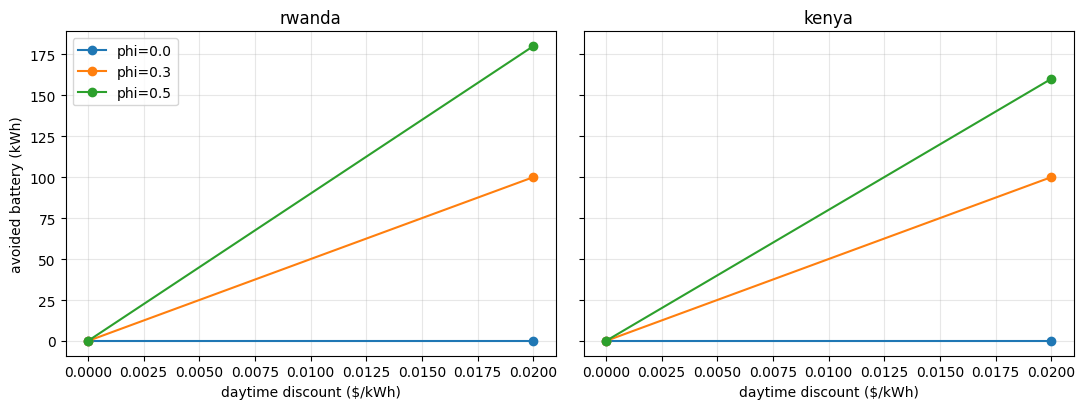

In [22]:
top = F.penetration.max()
fig, axes = plt.subplots(1,2, figsize=(11,4.2), sharey=True)
for ax, site in zip(axes, SITES):
    for phi, g in F[(F.site==site)&(F.penetration==top)].groupby("phi"):
        g=g.sort_values("discount")
        ax.plot(g.discount, g.avoided_battery_kwh, marker="o", label=f"phi={phi}")
    ax.set_title(site); ax.set_xlabel("daytime discount ($/kWh)"); ax.grid(alpha=.3)
axes[0].set_ylabel("avoided battery (kWh)"); axes[0].legend()
plt.tight_layout(); plt.savefig("figs/fig5_substitution_both.png", dpi=150); plt.show()

## 9 · Viability: subsidy and cost-reflective tariff

At regulated tariffs these projects do not clear a commercial hurdle. Two
questions follow: how much capital grant would fix it, and what tariff would?

In [ ]:
from model import required_subsidy, required_tariff
from run_scenarios import make_load_builder

rows=[]
for site, rep_year in SITES.items():
    d = pd.read_csv(f"data/processed/resource_{site}.csv", index_col=0, parse_dates=True)
    if rep_year: d = d[d.index.year==rep_year]
    d = d.iloc[:8760]
    resource = {"ghi": d["ALLSKY_SFC_SW_DWN"].values, "tair": d["T2M"].values}
    cfg = country_cfg(site)   # guarded: fails if appliances or opex basis unset

    sub = S[(S.site==site)&(S.feasible)&(S.penetration==S.penetration.max())&(S.tariff=="flat")]
    if sub.empty: continue
    r = sub.iloc[0]
    sizing = {"pv_kw":r.pv_kw,"battery_kwh":r.battery_kwh,"diesel_kw":0.0,
              "connections":CONNECTIONS,"households":N_HOUSEHOLDS}
    builder = make_load_builder(cfg, N_HOUSEHOLDS, r.penetration, 0.0, 42)

    frac, irr1 = required_subsidy(cfg, sizing, builder, resource, "flat")
    tar,  irr2 = required_tariff(cfg, sizing, builder, resource)
    reg = cfg["tariff"]["flat_rate_per_kwh"]
    rows.append({"site":site, "regulated_tariff":round(reg,4),
                 "grant_fraction": round(frac,3) if frac else None,
                 "cost_reflective_tariff": round(tar,3) if tar else None,
                 "gap_per_kwh": round(tar-reg,3) if tar else None,
                 "multiple_of_regulated": round(tar/reg,1) if tar else None})
V = pd.DataFrame(rows); V.to_csv("results/viability.csv", index=False); V

## 10 · Seed robustness

Earlier, a ToU tariff with **zero** discount appeared to avoid 20 kWh of
battery. It should avoid nothing — no discount means no shifting. If that
persists across seeds, the two arms are leaking and the result is compromised.

In [ ]:
from sizing import size_system
site = "rwanda"
d = pd.read_csv(f"data/processed/resource_{site}.csv", index_col=0, parse_dates=True)
d = d[d.index.year==SITES[site]].iloc[:8760]
resource = {"ghi": d["ALLSKY_SFC_SW_DWN"].values, "tair": d["T2M"].values}
cfg = country_cfg(site)

out=[]
for seed in [42, 7, 2026]:
    b = make_load_builder(cfg, N_HOUSEHOLDS, 1.0, 0.0, seed)
    r=[]
    for mode in ["flat","tou"]:
        c = {**cfg, "_tariff_mode": mode}
        s_,m_,_ = size_system(c, b, resource, CONNECTIONS, 0.0,
                              cfg["reliability"]["max_unmet_demand_fraction"],
                              tuple(cfg["sizing"]["pv_range"]),
                              tuple(cfg["sizing"]["battery_range"]))
        r.append(s_["battery_kwh"] if s_ else None)
    out.append({"seed":seed,"battery_flat":r[0],"battery_tou":r[1],"difference":r[0]-r[1]})
R = pd.DataFrame(out)
print(R.to_string(index=False))
print("\nPASS - no leakage" if (R.difference.abs()<1e-9).all()
      else "\nDIFFERENCES AT ZERO DISCOUNT - investigate before trusting the frontier")

## 11 · Discount-rate sweep

No published cost-of-capital benchmark exists for East African mini-grids, so the discount rate is swept rather than assumed. The absence of a benchmark is itself a reportable finding.

In [ ]:
from model import simulate, required_tariff
from run_scenarios import make_load_builder

# Discount-rate sweep. No published East African mini-grid cost-of-capital
# benchmark exists, so this is swept rather than assumed - and the absence is
# itself reportable.
rows=[]
for site, rep_year in SITES.items():
    d = pd.read_csv(f"data/processed/resource_{site}.csv", index_col=0, parse_dates=True)
    if rep_year: d = d[d.index.year==rep_year]
    d = d.iloc[:8760]
    resource = {"ghi": d["ALLSKY_SFC_SW_DWN"].values, "tair": d["T2M"].values}
    base = country_cfg(site)
    sub = S[(S.site==site)&(S.feasible)&(S.penetration==S.penetration.max())&(S.tariff=="flat")]
    if sub.empty: continue
    r = sub.iloc[0]
    sizing = {"pv_kw":r.pv_kw,"battery_kwh":r.battery_kwh,"diesel_kw":0.0,
              "connections":CONNECTIONS,"households":N_HOUSEHOLDS}
    builder = make_load_builder(base, N_HOUSEHOLDS, r.penetration, 0.0, 42)
    for dr in DISCOUNT_RATES:
        c = {k:(v.copy() if isinstance(v,dict) else v) for k,v in base.items()}
        c["finance"] = {**base["finance"], "discount_rate_real": dr, "target_irr": dr+0.03}
        _, m = simulate(c, sizing, builder, resource, "flat")
        tar, _ = required_tariff(c, sizing, builder, resource)
        rows.append({"site":site,"discount_rate":dr,"target_irr":round(dr+0.03,2),
                     "lcoe":round(m["lcoe"],3),"npv":round(m["npv"]),
                     "cost_reflective_tariff":round(tar,3) if tar else None,
                     "multiple_of_regulated":
                        round(tar/c["tariff"]["flat_rate_per_kwh"],1) if tar else None})
D = pd.DataFrame(rows); D.to_csv("results/discount_sweep.csv", index=False)
print(D.to_string(index=False))

## 12 · Report block — copy all of this back

In [ ]:
print("="*64); print("ECOOKING PIPELINE REPORT v2"); print("="*64)
try:
    rs = pd.read_csv("data/processed/resource_summary.csv")
    print("\n[RESOURCE]")
    for site,g in rs.groupby("site"):
        med=g.ghi_kwh_m2_yr.median()
        rep=int(g.iloc[(g.ghi_kwh_m2_yr-med).abs().argsort().iloc[0]].year)
        print(f"  {site}: median GHI {med:.0f} | spread "
              f"{100*(g.ghi_kwh_m2_yr.max()-g.ghi_kwh_m2_yr.min())/med:.1f}% | rep {rep}")
except Exception as e: print("  resource: ", e)
print("\n[TARIFF BANDS]")
for site in SITES:
    t={**BASE_CFG["tariff"], **COUNTRY_OVERRIDES[site]["tariff"]}
    print(f"  {site}: 15 kWh/mo ${_band_rate(15,t):.4f} -> 60 kWh/mo ${_band_rate(60,t):.4f}"
          f"  ({_band_rate(60,t)/_band_rate(15,t):.1f}x)")
print("\n[SCENARIOS]")
cols=["site","penetration","phi","phi_effective","tariff","discount","pv_kw",
      "battery_kwh","lcoe","npv","irr","unmet_fraction","capex"]
print(S[[c for c in cols if c in S.columns]].to_string(index=False))
print("\n[FRONTIER]")
print(F[["site","penetration","phi","discount","battery_flat","battery_kwh",
         "avoided_battery_kwh","lcoe"]].to_string(index=False))
print("\n[VIABILITY]"); print(V.to_string(index=False))
print("\n[SEED ROBUSTNESS]"); print(R.to_string(index=False))
print("\n[DISCOUNT SWEEP]"); print(D.to_string(index=False))
print("\n"+"="*64)

## 13 · Phase 1 impact on the published headline numbers

Sizing held at the published least-cost capacities so the comparison isolates the OPEX-basis change. `capex_fraction` reproduces the submitted numbers exactly, which validates the chain.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path(__file__).resolve().parent / "src"))

import final_cfg
from model import required_subsidy, required_tariff, simulate
from run_scenarios import make_load_builder

N = CONN = 300
SITES = {"rwanda": (2015, 305.0, 640.0), "kenya": (2007, 275.0, 600.0)}
PUBLISHED = {"rwanda": dict(lcoe=1.248, tariff=1.597, mult=10.9),
             "kenya": dict(lcoe=1.161, tariff=1.484, mult=11.6)}


def resource(site, year):
    d = pd.read_csv(f"data/processed/resource_{site}.csv",
                    index_col=0, parse_dates=True)
    d = d[d.index.year == year].iloc[:8760]
    return {"ghi": d["ALLSKY_SFC_SW_DWN"].values, "tair": d["T2M"].values}


def cfg_for(site, basis):
    cfg = {k: (v.copy() if isinstance(v, dict) else v)
           for k, v in final_cfg.BASE_CFG.items()}
    for k, v in final_cfg.COUNTRY_OVERRIDES[site].items():
        cfg[k] = {**cfg[k], **v} if isinstance(v, dict) and isinstance(cfg.get(k), dict) else v
    # Reproduce the as-submitted behaviour: Rwanda ran on the Kenyan appliance
    # set. Made explicit here rather than inherited by accident.
    cfg["appliances"] = final_cfg.APPLIANCES_KENYA
    cfg["opex"] = {**cfg["opex"], "basis": basis}
    return cfg


rows = []
for site, (year, pv, batt) in SITES.items():
    res = resource(site, year)
    sizing = {"pv_kw": pv, "battery_kwh": batt, "diesel_kw": 0.0,
              "connections": CONN, "households": N}
    for basis in ("capex_fraction", "per_customer"):
        cfg = cfg_for(site, basis)
        builder = make_load_builder(cfg, N, 1.0, 0.0, 42)
        _, m = simulate(cfg, sizing, builder, res, "flat")
        tar, _ = required_tariff(cfg, sizing, builder, res)
        frac, best_irr = required_subsidy(cfg, sizing, builder, res, "flat")
        reg = cfg["tariff"]["flat_rate_per_kwh"]
        rows.append({
            "site": site, "opex_basis": basis,
            "opex_yr1": round(cfg["opex"]["per_customer_year"] * CONN
                              if basis == "per_customer"
                              else m["gross_capex"] * 0.04 + 6000),
            "lcoe": round(m["lcoe"], 3),
            "npv_musd": round(m["npv"] / 1e6, 2),
            "curtailed_pct": round(100 * m["curtailed_fraction"], 1),
            "grant": "none" if frac is None else round(frac, 3),
            "cost_reflective": round(tar, 3) if tar else None,
            "multiple": round(tar / reg, 1) if tar else None,
        })

D = pd.DataFrame(rows)
print("\n" + "=" * 78)
print("PHASE 1 IMPACT - full eCooking penetration, published sizing, flat tariff")
print("=" * 78)
print(D.to_string(index=False))

print("\nAgainst the published table:")
for site in SITES:
    p = PUBLISHED[site]
    old = D[(D.site == site) & (D.opex_basis == "capex_fraction")].iloc[0]
    new = D[(D.site == site) & (D.opex_basis == "per_customer")].iloc[0]
    print(f"  {site:<7} LCOE    published {p['lcoe']:.3f} | "
          f"reproduced {old.lcoe:.3f} | corrected {new.lcoe:.3f} "
          f"({100*(new.lcoe-p['lcoe'])/p['lcoe']:+.0f}%)")
    print(f"  {site:<7} tariff  published {p['tariff']:.3f} | "
          f"reproduced {old.cost_reflective:.3f} | corrected {new.cost_reflective:.3f}")
    print(f"  {site:<7} x reg   published {p['mult']:.1f}x | "
          f"reproduced {old.multiple:.1f}x | corrected {new.multiple:.1f}x")

Path("results").mkdir(exist_ok=True)
D.to_csv("results/phase1_impact.csv", index=False)
print("\nwrote results/phase1_impact.csv")
